<h1>VAE (Problem Statement 1)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ==========================================
# 1. VAE ARCHITECTURE
# ==========================================
#Instead of compressing the image into a single point, it compresses the image into a probability distribution (a bell curve).
class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 28 * 28)
        
    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)
    #To get the final compressed numbers to send to the decoder, the VAE randomly samples a point from the bell curve created by mu and logvar.
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    #The decoder takes that randomly sampled point (z) and passes it through a series of expanding layers (fc3, fc4). Its goal is to blow those few numbers back up into a 28x28 pixel grid.
    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))
    
    def forward(self, x):
        x = x.view(-1, 28 * 28)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss_function(recon_x, x, mu, logvar, kl_weight):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 28 * 28), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + (kl_weight * KLD)

# ==========================================
# 2. SETUP & TRAINING LOOP
# ==========================================
# Hardware acceleration setup
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Executing on device: {device}")

LATENT_DIM = 32
DATASET = 'fashion_mnist'
EPOCHS = 20
BATCH_SIZE = 128

# Dataloader
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Initialize Model and Optimizer
model = VAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Starting VAE Training... This will take a few minutes.")

model.train()
for epoch in range(1, EPOCHS + 1):
    train_loss = 0
    # KL Annealing: Linearly warm up from 0 to 1 over the first 10 epochs
    kl_weight = min(1.0, epoch / 10.0)
    
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = vae_loss_function(recon_batch, data, mu, logvar, kl_weight)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    avg_loss = train_loss / len(train_loader.dataset)
    print(f"Epoch: {epoch}/{EPOCHS} | Avg Loss: {avg_loss:.4f} | KL Weight: {kl_weight:.2f}")

# Save the weights!
MODEL_PATH = f"vae_{DATASET}_z{LATENT_DIM}.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Training complete! Model saved to {MODEL_PATH}")

Executing on device: mps
Starting VAE Training... This will take a few minutes.
Epoch: 1/20 | Avg Loss: 265.0532 | KL Weight: 0.10
Epoch: 2/20 | Avg Loss: 239.0926 | KL Weight: 0.20
Epoch: 3/20 | Avg Loss: 236.8842 | KL Weight: 0.30
Epoch: 4/20 | Avg Loss: 237.1693 | KL Weight: 0.40
Epoch: 5/20 | Avg Loss: 238.2198 | KL Weight: 0.50
Epoch: 6/20 | Avg Loss: 239.4582 | KL Weight: 0.60
Epoch: 7/20 | Avg Loss: 240.7915 | KL Weight: 0.70
Epoch: 8/20 | Avg Loss: 242.1868 | KL Weight: 0.80
Epoch: 9/20 | Avg Loss: 243.5446 | KL Weight: 0.90
Epoch: 10/20 | Avg Loss: 244.8477 | KL Weight: 1.00
Epoch: 11/20 | Avg Loss: 244.2814 | KL Weight: 1.00
Epoch: 12/20 | Avg Loss: 243.8032 | KL Weight: 1.00
Epoch: 13/20 | Avg Loss: 243.3325 | KL Weight: 1.00
Epoch: 14/20 | Avg Loss: 243.0034 | KL Weight: 1.00
Epoch: 15/20 | Avg Loss: 242.7141 | KL Weight: 1.00
Epoch: 16/20 | Avg Loss: 242.3990 | KL Weight: 1.00
Epoch: 17/20 | Avg Loss: 242.1525 | KL Weight: 1.00
Epoch: 18/20 | Avg Loss: 241.8954 | KL Weight

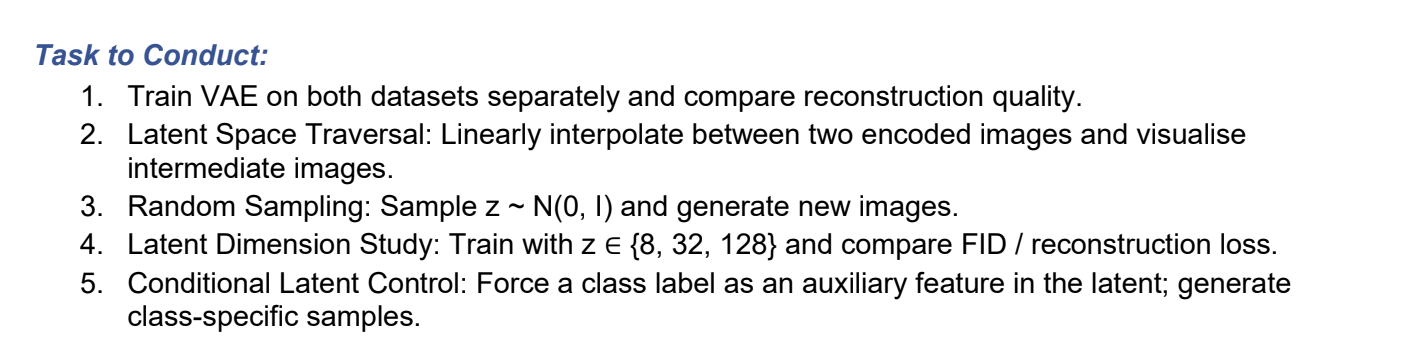

Executing Task 3: Random Sampling...


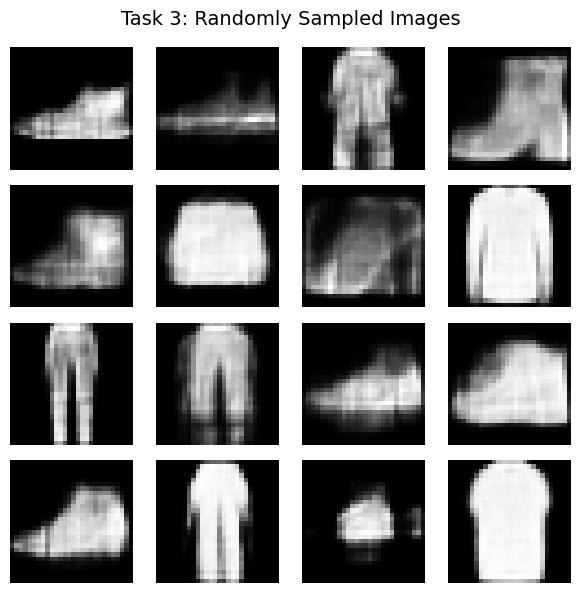

Executing Task 2: Latent Interpolation...


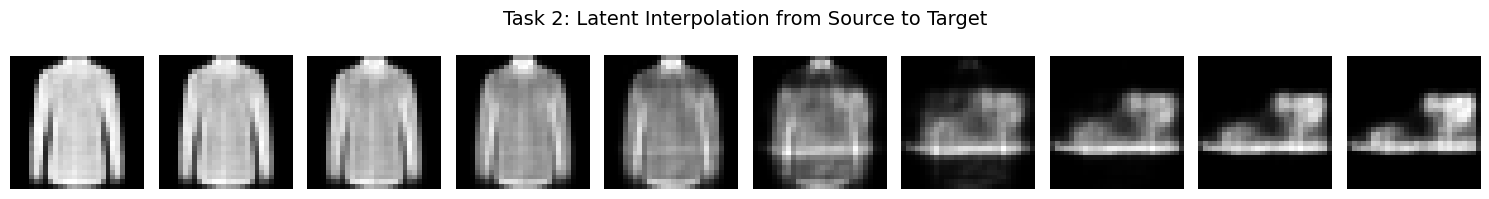

In [9]:
# ==========================================
# CELL 2: EVALUATE THE VAE (TASKS 2 & 3)
# ==========================================
import torch
import matplotlib.pyplot as plt

# Ensure the model is in evaluation mode
model.eval()

# Task 3: Random Sampling
def task3_random_sampling(num_samples=16):
    print("Executing Task 3: Random Sampling...")
    z = torch.randn(num_samples, LATENT_DIM).to(device)
    with torch.no_grad():
        generated_imgs = model.decode(z).cpu().view(-1, 28, 28)
    
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    fig.suptitle("Task 3: Randomly Sampled Images", fontsize=14)
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(generated_imgs[i], cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Task 2: Latent Interpolation
def task2_latent_interpolation(steps=10):
    print("Executing Task 2: Latent Interpolation...")
    dataiter = iter(train_loader)
    images, _ = next(dataiter)
    
    img1, img2 = images[0].to(device), images[1].to(device)
    
    with torch.no_grad():
        mu1, _ = model.encode(img1.view(-1, 28 * 28))
        mu2, _ = model.encode(img2.view(-1, 28 * 28))
        
        alphas = torch.linspace(0, 1, steps).to(device)
        interpolated_z = torch.stack([(1 - a)*mu1[0] + a*mu2[0] for a in alphas])
        generated_imgs = model.decode(interpolated_z).cpu().view(-1, 28, 28)
        
    fig, axes = plt.subplots(1, steps, figsize=(15, 2))
    fig.suptitle("Task 2: Latent Interpolation from Source to Target", fontsize=14)
    for i in range(steps):
        axes[i].imshow(generated_imgs[i], cmap='gray')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Execute tasks
task3_random_sampling()
task2_latent_interpolation()

Starting Latent Dimension Study...

--- Training VAE with z=8 ---
Epoch 1/10 | Avg Loss: 263.6052
Epoch 2/10 | Avg Loss: 238.0473
Epoch 3/10 | Avg Loss: 236.7170
Epoch 4/10 | Avg Loss: 236.9323
Epoch 5/10 | Avg Loss: 237.6018
Epoch 6/10 | Avg Loss: 238.5659
Epoch 7/10 | Avg Loss: 239.5865
Epoch 8/10 | Avg Loss: 240.7360
Epoch 9/10 | Avg Loss: 241.8294
Epoch 10/10 | Avg Loss: 243.0032

--- Training VAE with z=128 ---
Epoch 1/10 | Avg Loss: 268.0149
Epoch 2/10 | Avg Loss: 244.5049
Epoch 3/10 | Avg Loss: 241.3472
Epoch 4/10 | Avg Loss: 239.6335
Epoch 5/10 | Avg Loss: 239.3541
Epoch 6/10 | Avg Loss: 239.7615
Epoch 7/10 | Avg Loss: 240.6807
Epoch 8/10 | Avg Loss: 241.7878
Epoch 9/10 | Avg Loss: 243.0829
Epoch 10/10 | Avg Loss: 244.3870


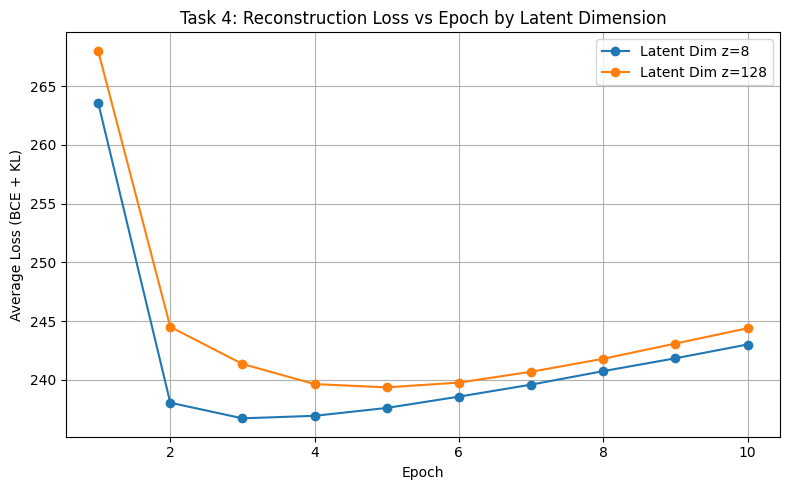

In [10]:
# ==========================================
# CELL 3: LATENT DIMENSION STUDY (TASK 4)
# ==========================================
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

# We only need a few epochs to see the trend for the study
STUDY_EPOCHS = 10 
dimensions_to_test = [8, 128] # We skip 32 since we already know it works well
loss_history = {}

print("Starting Latent Dimension Study...")

for dim in dimensions_to_test:
    print(f"\n--- Training VAE with z={dim} ---")
    
    # Initialize a fresh model for this dimension
    test_model = VAE(latent_dim=dim).to(device)
    optimizer = optim.Adam(test_model.parameters(), lr=1e-3)
    test_model.train()
    
    epoch_losses = []
    
    for epoch in range(1, STUDY_EPOCHS + 1):
        train_loss = 0
        kl_weight = min(1.0, epoch / 10.0)
        
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            recon_batch, mu, logvar = test_model(data)
            loss = vae_loss_function(recon_batch, data, mu, logvar, kl_weight)
            loss.backward()
            train_loss += loss.item()
            optimizer.step()
            
        avg_loss = train_loss / len(train_loader.dataset)
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch}/{STUDY_EPOCHS} | Avg Loss: {avg_loss:.4f}")
        
    loss_history[dim] = epoch_losses

# Plot the comparison
plt.figure(figsize=(8, 5))
for dim, losses in loss_history.items():
    plt.plot(range(1, STUDY_EPOCHS + 1), losses, label=f'Latent Dim z={dim}', marker='o')

plt.title("Task 4: Reconstruction Loss vs Epoch by Latent Dimension")
plt.xlabel("Epoch")
plt.ylabel("Average Loss (BCE + KL)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Executing CVAE on device: mps
Starting Conditional VAE Training...
Epoch 1/15 | Avg Loss: 258.4769
Epoch 2/15 | Avg Loss: 236.4472
Epoch 3/15 | Avg Loss: 233.9159
Epoch 4/15 | Avg Loss: 233.5435
Epoch 5/15 | Avg Loss: 233.9148
Epoch 6/15 | Avg Loss: 234.6076
Epoch 7/15 | Avg Loss: 235.5420
Epoch 8/15 | Avg Loss: 236.5947
Epoch 9/15 | Avg Loss: 237.6035
Epoch 10/15 | Avg Loss: 238.6612
Epoch 11/15 | Avg Loss: 238.3167
Epoch 12/15 | Avg Loss: 237.9552
Epoch 13/15 | Avg Loss: 237.6441
Epoch 14/15 | Avg Loss: 237.4248
Epoch 15/15 | Avg Loss: 237.2004
✅ CVAE Training Complete!

Generating Class-Specific Samples (Task 5)...


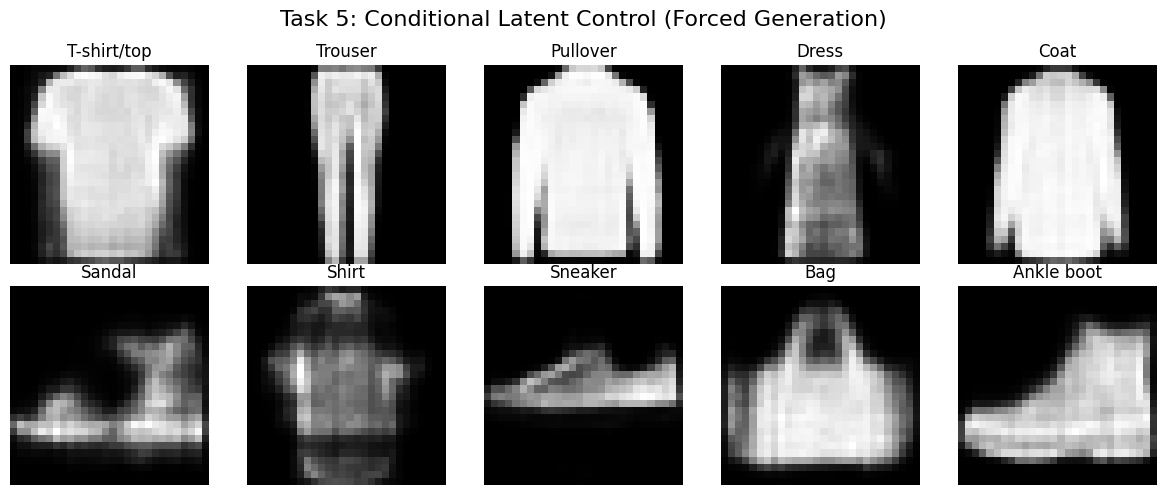

In [11]:
# ==========================================
# CELL 4: CONDITIONAL VAE (TASK 5)
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Conditional VAE Architecture
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim=32, num_classes=10, embed_dim=50):
        super(ConditionalVAE, self).__init__()
        # Embedding layer to turn class labels (0-9) into dense vectors
        self.embed = nn.Embedding(num_classes, embed_dim)
        
        # ENCODER: Image (784) + Embedded Label (50) = 834
        self.fc1 = nn.Linear(28 * 28 + embed_dim, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        
        # DECODER: Latent z (32) + Embedded Label (50) = 82
        self.fc3 = nn.Linear(latent_dim + embed_dim, 400)
        self.fc4 = nn.Linear(400, 28 * 28)
        
    def encode(self, x, c):
        inputs = torch.cat([x, c], dim=1) # Concatenate image and label
        h1 = F.relu(self.fc1(inputs))
        return self.fc_mu(h1), self.fc_logvar(h1)
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
        
    def decode(self, z, c):
        inputs = torch.cat([z, c], dim=1) # Concatenate noise and label
        h3 = F.relu(self.fc3(inputs))
        return torch.sigmoid(self.fc4(h3))
        
    def forward(self, x, labels):
        x = x.view(-1, 28 * 28)
        c = self.embed(labels)
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar

def vae_loss_function(recon_x, x, mu, logvar, kl_weight):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 28 * 28), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + (kl_weight * KLD)

# 2. Setup & Training
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Executing CVAE on device: {device}")

LATENT_DIM = 32
EPOCHS = 15 # Shorter epoch count since we just need to prove it works
BATCH_SIZE = 128

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

cvae_model = ConditionalVAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(cvae_model.parameters(), lr=1e-3)

print("Starting Conditional VAE Training...")
cvae_model.train()
for epoch in range(1, EPOCHS + 1):
    train_loss = 0
    kl_weight = min(1.0, epoch / 10.0)
    
    # Notice we now unpack the labels (y) from the dataloader
    for batch_idx, (data, labels) in enumerate(train_loader):
        data, labels = data.to(device), labels.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar = cvae_model(data, labels)
        loss = vae_loss_function(recon_batch, data, mu, logvar, kl_weight)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    print(f"Epoch {epoch}/{EPOCHS} | Avg Loss: {train_loss / len(train_loader.dataset):.4f}")

print("✅ CVAE Training Complete!")

# ==========================================
# 3. TASK 5 EVALUATION: CLASS-SPECIFIC GENERATION
# ==========================================
cvae_model.eval()
print("\nGenerating Class-Specific Samples (Task 5)...")

# We want one of each class (0 through 9)
target_labels = torch.arange(0, 10).to(device)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Generate random noise
z = torch.randn(10, LATENT_DIM).to(device)

with torch.no_grad():
    # Embed the target labels and decode
    c = cvae_model.embed(target_labels)
    generated_imgs = cvae_model.decode(z, c).cpu().view(-1, 28, 28)

# Plotting the controlled generation
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Task 5: Conditional Latent Control (Forced Generation)", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_imgs[i], cmap='gray')
    ax.set_title(class_names[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

<h1>Vanilla GAN (Problem Statement 2)

Starting Vanilla GAN Training...
Epoch 1/50 | D loss: 0.5315 | G loss: 1.4820
Epoch 2/50 | D loss: 0.4754 | G loss: 2.0725
Epoch 3/50 | D loss: 0.5083 | G loss: 1.6953
Epoch 4/50 | D loss: 0.5848 | G loss: 1.3406
Epoch 5/50 | D loss: 0.6561 | G loss: 1.2750


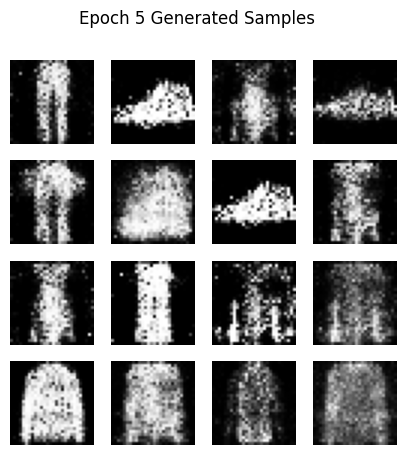

Epoch 6/50 | D loss: 0.6137 | G loss: 1.1971
Epoch 7/50 | D loss: 0.6363 | G loss: 1.2482
Epoch 8/50 | D loss: 0.6392 | G loss: 1.0300
Epoch 9/50 | D loss: 0.6328 | G loss: 1.0113
Epoch 10/50 | D loss: 0.6729 | G loss: 1.1615


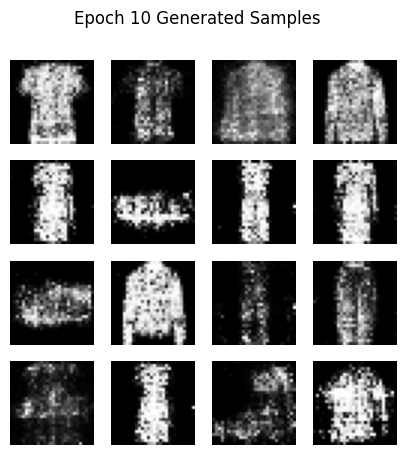

Epoch 11/50 | D loss: 0.6410 | G loss: 1.1366
Epoch 12/50 | D loss: 0.6629 | G loss: 1.0024
Epoch 13/50 | D loss: 0.6637 | G loss: 0.9622
Epoch 14/50 | D loss: 0.6769 | G loss: 0.9725
Epoch 15/50 | D loss: 0.6543 | G loss: 0.9859


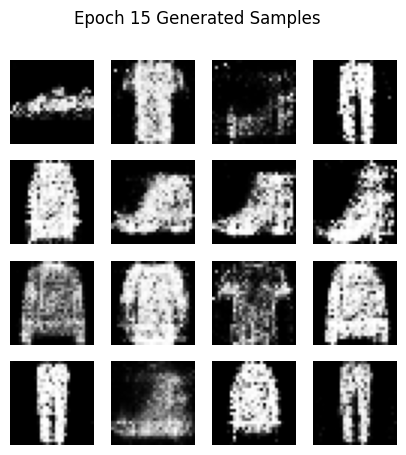

Epoch 16/50 | D loss: 0.6755 | G loss: 0.9239
Epoch 17/50 | D loss: 0.6753 | G loss: 0.9437
Epoch 18/50 | D loss: 0.6626 | G loss: 0.9324
Epoch 19/50 | D loss: 0.6560 | G loss: 0.9149
Epoch 20/50 | D loss: 0.6673 | G loss: 0.9306


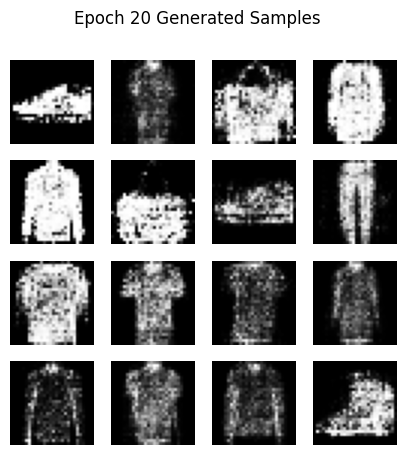

Epoch 21/50 | D loss: 0.6644 | G loss: 0.9409
Epoch 22/50 | D loss: 0.6574 | G loss: 0.9309
Epoch 23/50 | D loss: 0.6742 | G loss: 0.9397
Epoch 24/50 | D loss: 0.7020 | G loss: 0.8476
Epoch 25/50 | D loss: 0.6638 | G loss: 0.9241


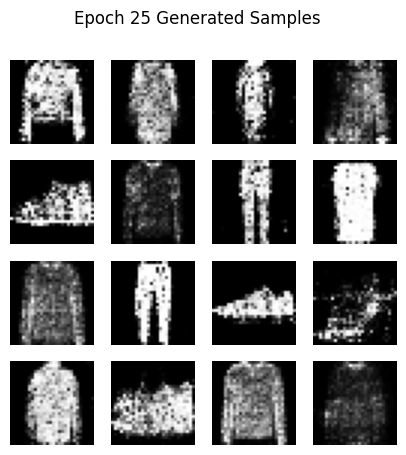

Epoch 26/50 | D loss: 0.6879 | G loss: 0.8811
Epoch 27/50 | D loss: 0.6678 | G loss: 0.9205
Epoch 28/50 | D loss: 0.6752 | G loss: 0.9095
Epoch 29/50 | D loss: 0.6681 | G loss: 0.8847
Epoch 30/50 | D loss: 0.6659 | G loss: 0.8808


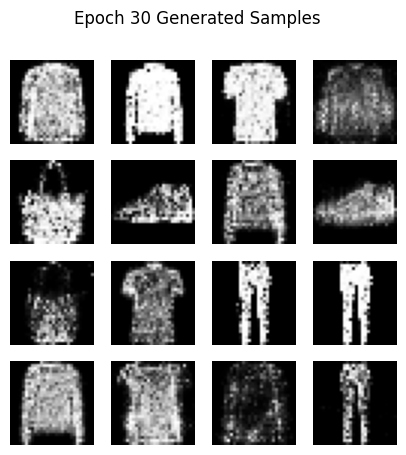

Epoch 31/50 | D loss: 0.6755 | G loss: 0.8998
Epoch 32/50 | D loss: 0.6976 | G loss: 0.8872
Epoch 33/50 | D loss: 0.6569 | G loss: 0.8797
Epoch 34/50 | D loss: 0.6801 | G loss: 0.8980
Epoch 35/50 | D loss: 0.6816 | G loss: 0.8389


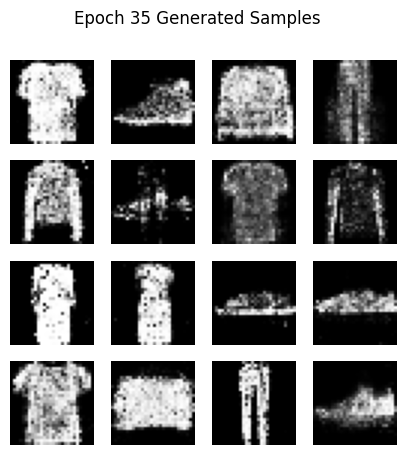

Epoch 36/50 | D loss: 0.6864 | G loss: 0.8531
Epoch 37/50 | D loss: 0.6725 | G loss: 0.9171
Epoch 38/50 | D loss: 0.6870 | G loss: 0.8830
Epoch 39/50 | D loss: 0.6864 | G loss: 0.8886
Epoch 40/50 | D loss: 0.6665 | G loss: 0.8701


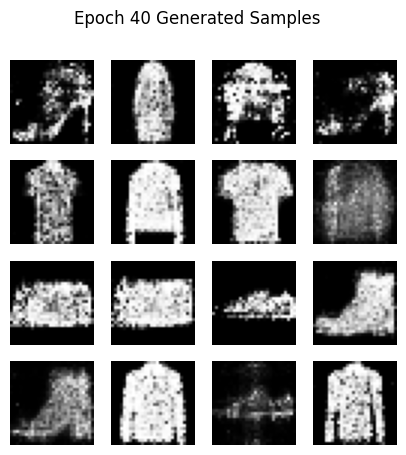

Epoch 41/50 | D loss: 0.6867 | G loss: 0.9113
Epoch 42/50 | D loss: 0.6912 | G loss: 0.8927
Epoch 43/50 | D loss: 0.6923 | G loss: 0.8844
Epoch 44/50 | D loss: 0.6986 | G loss: 0.8532
Epoch 45/50 | D loss: 0.6560 | G loss: 0.8597


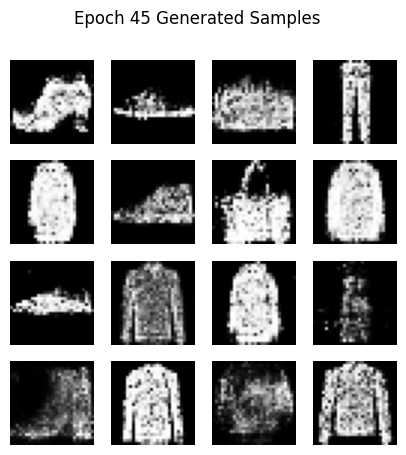

Epoch 46/50 | D loss: 0.6869 | G loss: 0.8747
Epoch 47/50 | D loss: 0.6736 | G loss: 0.9206
Epoch 48/50 | D loss: 0.6788 | G loss: 0.8298
Epoch 49/50 | D loss: 0.7002 | G loss: 0.8856
Epoch 50/50 | D loss: 0.6823 | G loss: 0.8746


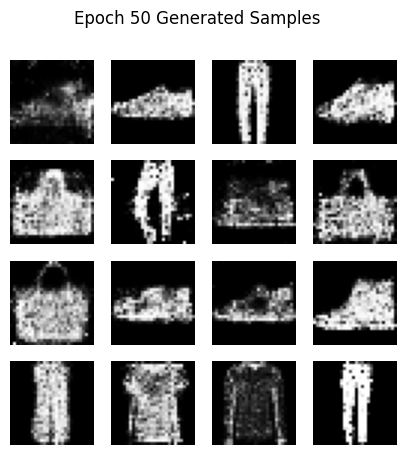

GAN Training Complete and models saved!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ==========================================
# 1. VANILLA GAN ARCHITECTURE
# ==========================================
#The Generator (The Forger) takes pure random noise and tries to paint a fake image.
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 28 * 28),
            nn.Tanh() # Required by the assignment for the output
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(-1, 1, 28, 28)
# The Discriminator (The Detective) looks at a mix of real images and the Generator's fake images, and tries to guess which is which.
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3), # Required by the assignment
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid() # Scalar probability
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity

# ==========================================
# 2. SETUP & HARDWARE
# ==========================================
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

LATENT_DIM = 100 # Assignment requires z in N(0,1) of dim 100
EPOCHS = 50
BATCH_SIZE = 128
LR = 0.0002

# The GAN needs images scaled between -1 and 1 because of the Tanh activation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Initialize models
generator = Generator(latent_dim=LATENT_DIM).to(device)
discriminator = Discriminator().to(device)

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))

# Loss function
criterion = nn.BCELoss()

# ==========================================
# 3. TRAINING LOOP WITH LABEL SMOOTHING
# ==========================================
print("Starting Vanilla GAN Training...")

g_losses = []
d_losses = []

for epoch in range(1, EPOCHS + 1):
    for i, (imgs, _) in enumerate(dataloader):
        
        batch_size = imgs.shape[0]
        
        # Adversarial ground truths with Label Smoothing (0.9 for real, 0.0 for fake)
        valid = torch.full((batch_size, 1), 0.9, device=device, dtype=torch.float32)
        fake = torch.full((batch_size, 1), 0.0, device=device, dtype=torch.float32)
        
        real_imgs = imgs.to(device)

        # -----------------
        #  Train Discriminator
        # -----------------
        optimizer_D.zero_grad()
        
        # Loss for real images
        real_loss = criterion(discriminator(real_imgs), valid)
        
        # Loss for fake images
        z = torch.randn(batch_size, LATENT_DIM, device=device)
        gen_imgs = generator(z)
        fake_loss = criterion(discriminator(gen_imgs.detach()), fake) # Detach to not train G here
        
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()
        
        # Generator wants the discriminator to think its images are real (target = 1.0, NOT smoothed)
        target_valid = torch.full((batch_size, 1), 1.0, device=device, dtype=torch.float32)
        g_loss = criterion(discriminator(gen_imgs), target_valid)
        
        g_loss.backward()
        optimizer_G.step()

    # Track losses for plotting later (Task 8)
    d_losses.append(d_loss.item())
    g_losses.append(g_loss.item())

    print(f"Epoch {epoch}/{EPOCHS} | D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}")

    # Task 6: Generate image grids every 5 epochs
    if epoch % 5 == 0:
        with torch.no_grad():
            z = torch.randn(16, LATENT_DIM, device=device)
            sample_imgs = generator(z).cpu().detach()
            
            fig, axes = plt.subplots(4, 4, figsize=(5, 5))
            fig.suptitle(f"Epoch {epoch} Generated Samples")
            for idx, ax in enumerate(axes.flatten()):
                # Un-normalize from [-1, 1] back to [0, 1] for displaying
                ax.imshow(sample_imgs[idx][0] * 0.5 + 0.5, cmap='gray')
                ax.axis('off')
            plt.show()

# Save the models
torch.save(generator.state_dict(), "vanilla_gan_generator.pth")
torch.save(discriminator.state_dict(), "vanilla_gan_discriminator.pth")
print("GAN Training Complete and models saved!")

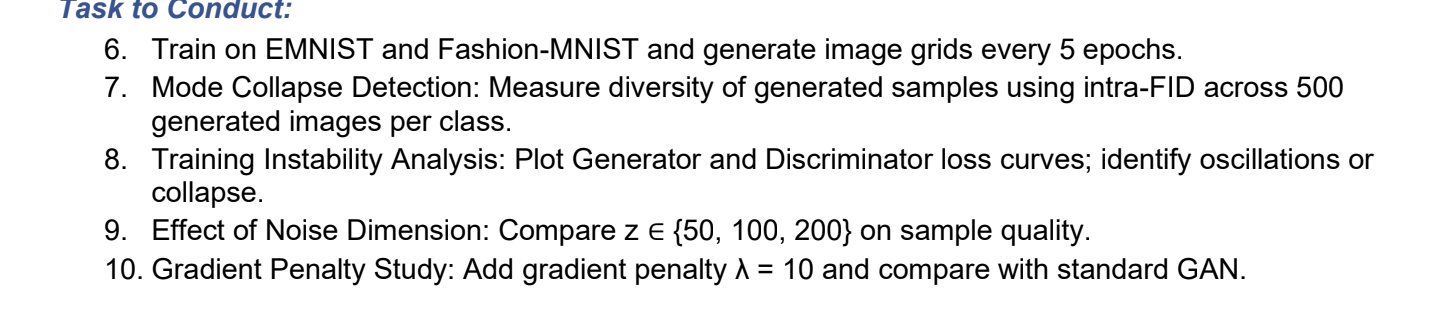

Executing Vanilla GAN on device: mps
Starting Vanilla GAN Training...
Epoch 1/50 | D loss: 0.4965 | G loss: 1.4643
Epoch 2/50 | D loss: 0.4999 | G loss: 1.9372
Epoch 3/50 | D loss: 0.5450 | G loss: 1.6438
Epoch 4/50 | D loss: 0.5712 | G loss: 1.4659
Epoch 5/50 | D loss: 0.5991 | G loss: 1.2855


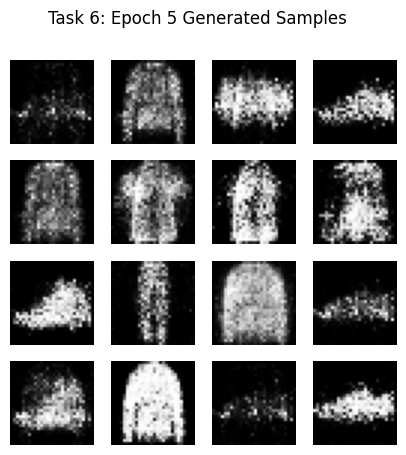

Epoch 6/50 | D loss: 0.6053 | G loss: 1.2583
Epoch 7/50 | D loss: 0.6170 | G loss: 1.1832
Epoch 8/50 | D loss: 0.6245 | G loss: 1.1520
Epoch 9/50 | D loss: 0.6326 | G loss: 1.0959
Epoch 10/50 | D loss: 0.6340 | G loss: 1.0900


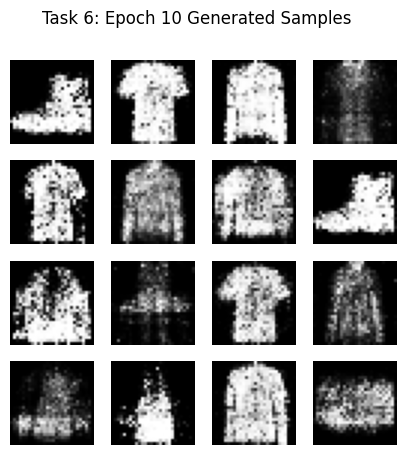

Epoch 11/50 | D loss: 0.6361 | G loss: 1.0740
Epoch 12/50 | D loss: 0.6392 | G loss: 1.0504
Epoch 13/50 | D loss: 0.6451 | G loss: 1.0351
Epoch 14/50 | D loss: 0.6490 | G loss: 1.0175
Epoch 15/50 | D loss: 0.6538 | G loss: 1.0047


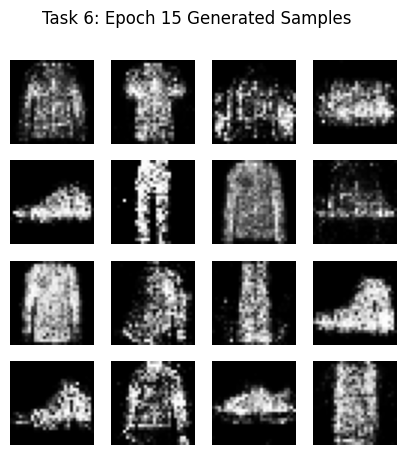

Epoch 16/50 | D loss: 0.6540 | G loss: 1.0007
Epoch 17/50 | D loss: 0.6559 | G loss: 0.9933
Epoch 18/50 | D loss: 0.6586 | G loss: 0.9803
Epoch 19/50 | D loss: 0.6607 | G loss: 0.9643
Epoch 20/50 | D loss: 0.6635 | G loss: 0.9593


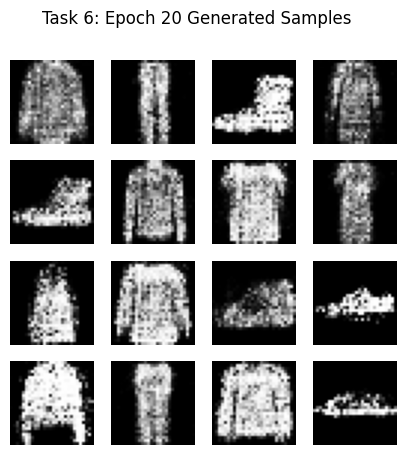

Epoch 21/50 | D loss: 0.6633 | G loss: 0.9510
Epoch 22/50 | D loss: 0.6647 | G loss: 0.9491
Epoch 23/50 | D loss: 0.6670 | G loss: 0.9360
Epoch 24/50 | D loss: 0.6686 | G loss: 0.9326
Epoch 25/50 | D loss: 0.6710 | G loss: 0.9214


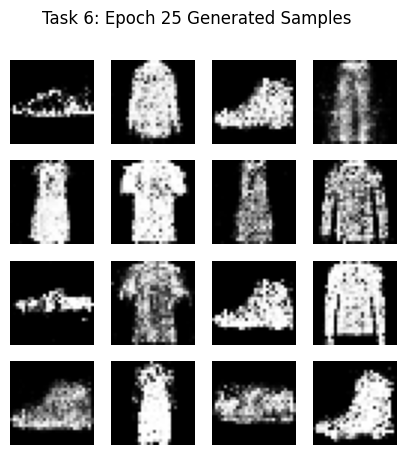

Epoch 26/50 | D loss: 0.6711 | G loss: 0.9172
Epoch 27/50 | D loss: 0.6704 | G loss: 0.9195
Epoch 28/50 | D loss: 0.6721 | G loss: 0.9091
Epoch 29/50 | D loss: 0.6720 | G loss: 0.9129
Epoch 30/50 | D loss: 0.6726 | G loss: 0.9107


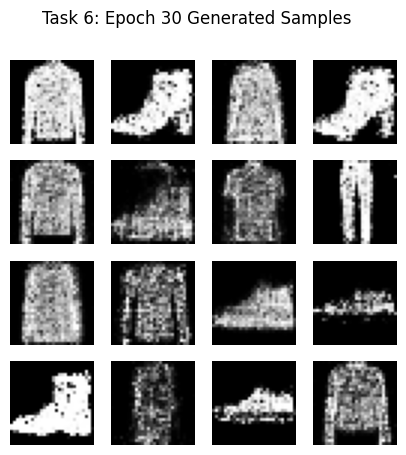

Epoch 31/50 | D loss: 0.6750 | G loss: 0.8980
Epoch 32/50 | D loss: 0.6742 | G loss: 0.8975
Epoch 33/50 | D loss: 0.6743 | G loss: 0.8941
Epoch 34/50 | D loss: 0.6753 | G loss: 0.8895
Epoch 35/50 | D loss: 0.6755 | G loss: 0.8860


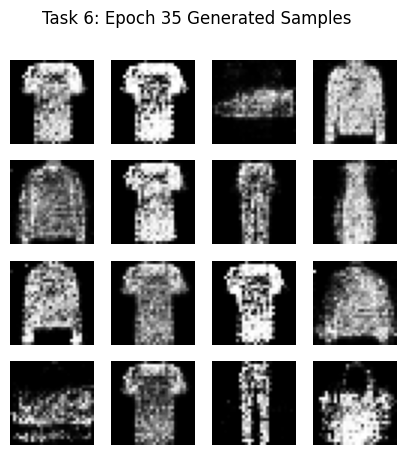

Epoch 36/50 | D loss: 0.6756 | G loss: 0.8850
Epoch 37/50 | D loss: 0.6758 | G loss: 0.8837
Epoch 38/50 | D loss: 0.6760 | G loss: 0.8846
Epoch 39/50 | D loss: 0.6760 | G loss: 0.8845
Epoch 40/50 | D loss: 0.6774 | G loss: 0.8778


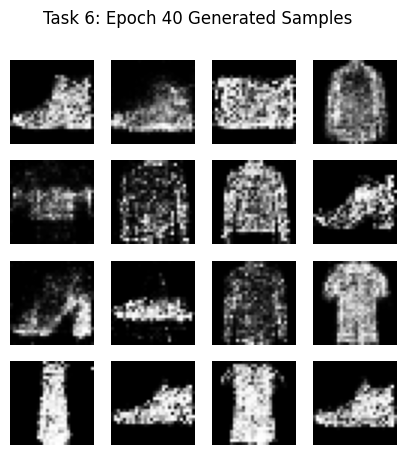

Epoch 41/50 | D loss: 0.6768 | G loss: 0.8783
Epoch 42/50 | D loss: 0.6773 | G loss: 0.8780
Epoch 43/50 | D loss: 0.6771 | G loss: 0.8762
Epoch 44/50 | D loss: 0.6768 | G loss: 0.8732
Epoch 45/50 | D loss: 0.6785 | G loss: 0.8714


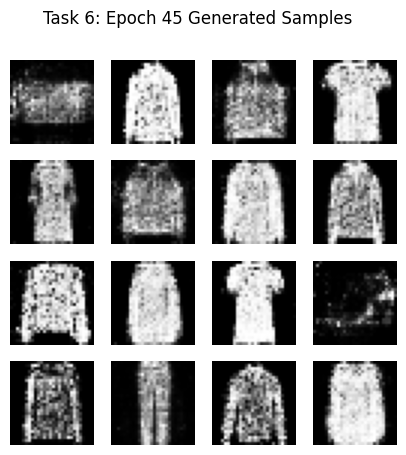

Epoch 46/50 | D loss: 0.6785 | G loss: 0.8640
Epoch 47/50 | D loss: 0.6786 | G loss: 0.8666
Epoch 48/50 | D loss: 0.6792 | G loss: 0.8646
Epoch 49/50 | D loss: 0.6787 | G loss: 0.8663
Epoch 50/50 | D loss: 0.6796 | G loss: 0.8619


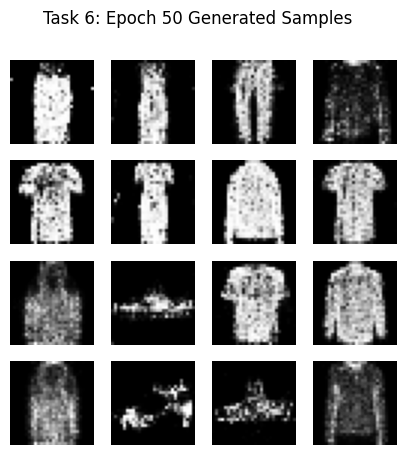

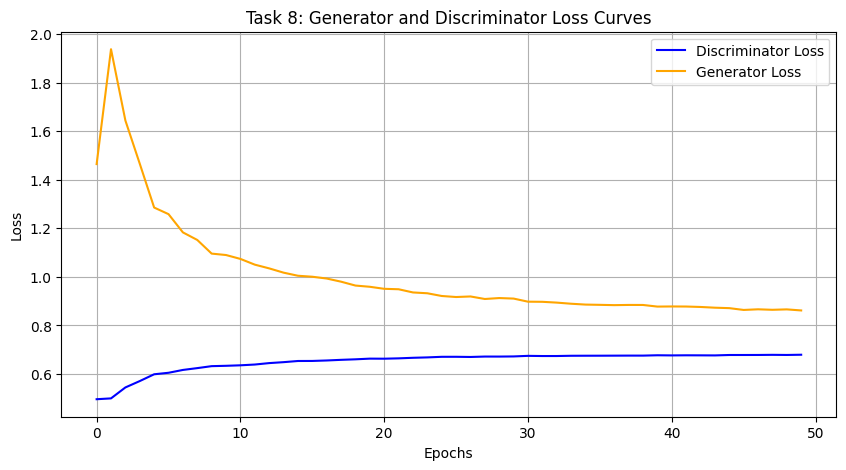

✅ Vanilla GAN Training Complete and models saved!


In [12]:
# ==========================================
# CELL 5: VANILLA GAN (TASKS 6 & 8)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 1. Architecture Requirements
class Generator(nn.Module):
    def __init__(self, latent_dim=100): # z ~ N(0,1) of dim 100
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 28 * 28),
            nn.Tanh() # Tanh activation required for output
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3), # Dropout 0.3 required by assignment
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid() # Single scalar probability
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1) # 784-dim flattened input
        return self.model(img_flat)

# 2. Setup & Hardware
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Executing Vanilla GAN on device: {device}")

LATENT_DIM = 100
EPOCHS = 50 # Recommended in standard GAN setups to see convergence
BATCH_SIZE = 128
LR = 0.0002

# The GAN needs images scaled between -1 and 1 because of the Generator's Tanh activation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

generator = Generator(latent_dim=LATENT_DIM).to(device)
discriminator = Discriminator().to(device)

# Separate optimizers with Beta1 = 0.5 for GAN stability
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# 3. Minimax Training Protocol
print("Starting Vanilla GAN Training...")
g_losses = []
d_losses = []

for epoch in range(1, EPOCHS + 1):
    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    
    for i, (imgs, _) in enumerate(dataloader):
        batch_size = imgs.shape[0]
        real_imgs = imgs.to(device)

        # Label smoothing: 0.9 for real, 0 for fake
        valid = torch.full((batch_size, 1), 0.9, device=device, dtype=torch.float32)
        fake = torch.full((batch_size, 1), 0.0, device=device, dtype=torch.float32)

        # -----------------
        #  Train Discriminator
        # -----------------
        optimizer_D.zero_grad()
        real_loss = criterion(discriminator(real_imgs), valid)
        
        z = torch.randn(batch_size, LATENT_DIM, device=device)
        gen_imgs = generator(z)
        fake_loss = criterion(discriminator(gen_imgs.detach()), fake) # Detach to avoid updating G
        
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()
        epoch_d_loss += d_loss.item()

        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()
        # Non-saturating variant: target is 1.0 (un-smoothed) to maximize log D(G(z))
        target_valid = torch.full((batch_size, 1), 1.0, device=device, dtype=torch.float32)
        g_loss = criterion(discriminator(gen_imgs), target_valid)
        
        g_loss.backward()
        optimizer_G.step()
        epoch_g_loss += g_loss.item()

    # Calculate average losses for the epoch
    avg_d_loss = epoch_d_loss / len(dataloader)
    avg_g_loss = epoch_g_loss / len(dataloader)
    d_losses.append(avg_d_loss)
    g_losses.append(avg_g_loss)

    print(f"Epoch {epoch}/{EPOCHS} | D loss: {avg_d_loss:.4f} | G loss: {avg_g_loss:.4f}")

    # Task 6: Generate image grids every 5 epochs
    if epoch % 5 == 0:
        with torch.no_grad():
            z = torch.randn(16, LATENT_DIM, device=device)
            sample_imgs = generator(z).cpu()
            
            fig, axes = plt.subplots(4, 4, figsize=(5, 5))
            fig.suptitle(f"Task 6: Epoch {epoch} Generated Samples")
            for idx, ax in enumerate(axes.flatten()):
                # Un-normalize from [-1, 1] back to [0, 1] for visual display
                ax.imshow(sample_imgs[idx][0] * 0.5 + 0.5, cmap='gray')
                ax.axis('off')
            plt.show()

# Task 8: Training Instability Analysis (Plot Loss Curves)
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label="Discriminator Loss", color='blue')
plt.plot(g_losses, label="Generator Loss", color='orange')
plt.title("Task 8: Generator and Discriminator Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

torch.save(generator.state_dict(), "vanilla_gan_generator.pth")
torch.save(discriminator.state_dict(), "vanilla_gan_discriminator.pth")
print("✅ Vanilla GAN Training Complete and models saved!")

Starting Task 9: Effect of Noise Dimension Study...

--- Training GAN with Latent Dimension z=50 ---
Epoch 1/15 Complete.
Epoch 2/15 Complete.
Epoch 3/15 Complete.
Epoch 4/15 Complete.
Epoch 5/15 Complete.
Epoch 6/15 Complete.
Epoch 7/15 Complete.
Epoch 8/15 Complete.
Epoch 9/15 Complete.
Epoch 10/15 Complete.
Epoch 11/15 Complete.
Epoch 12/15 Complete.
Epoch 13/15 Complete.
Epoch 14/15 Complete.
Epoch 15/15 Complete.

--- Training GAN with Latent Dimension z=200 ---
Epoch 1/15 Complete.
Epoch 2/15 Complete.
Epoch 3/15 Complete.
Epoch 4/15 Complete.
Epoch 5/15 Complete.
Epoch 6/15 Complete.
Epoch 7/15 Complete.
Epoch 8/15 Complete.
Epoch 9/15 Complete.
Epoch 10/15 Complete.
Epoch 11/15 Complete.
Epoch 12/15 Complete.
Epoch 13/15 Complete.
Epoch 14/15 Complete.
Epoch 15/15 Complete.


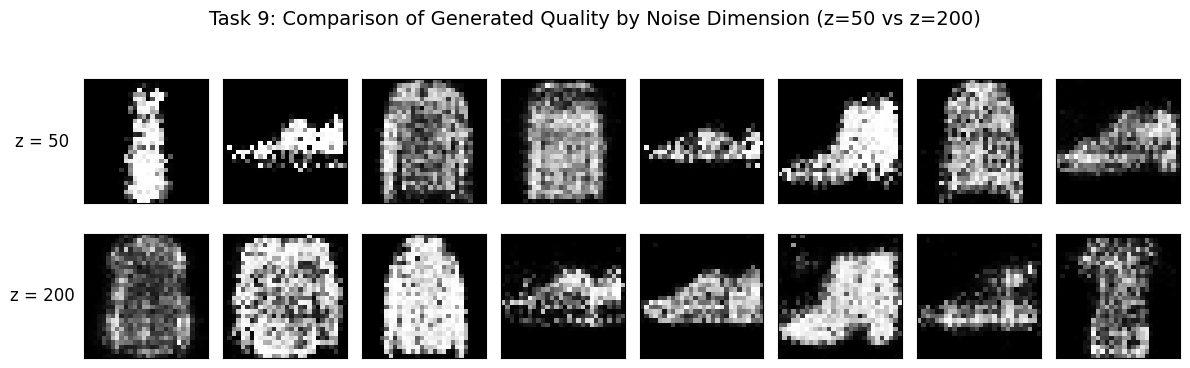

In [13]:
# ==========================================
# CELL 6: EFFECT OF NOISE DIMENSION (TASK 9)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# We only need about 15 epochs to see how quickly the model learns 
# based on the size of the noise vector.
STUDY_EPOCHS = 15
dimensions_to_test = [50, 200] # We skip 100 since that was your baseline in Cell 5

print("Starting Task 9: Effect of Noise Dimension Study...")

# Dictionary to hold the final generated images for comparison
generated_samples = {}

for dim in dimensions_to_test:
    print(f"\n--- Training GAN with Latent Dimension z={dim} ---")
    
    # Initialize fresh models for this specific dimension
    gen_test = Generator(latent_dim=dim).to(device)
    disc_test = Discriminator().to(device)
    
    opt_G = optim.Adam(gen_test.parameters(), lr=LR, betas=(0.5, 0.999))
    opt_D = optim.Adam(disc_test.parameters(), lr=LR, betas=(0.5, 0.999))
    
    for epoch in range(1, STUDY_EPOCHS + 1):
        for i, (imgs, _) in enumerate(dataloader):
            batch_size = imgs.shape[0]
            real_imgs = imgs.to(device)
            
            valid = torch.full((batch_size, 1), 0.9, device=device, dtype=torch.float32)
            fake = torch.full((batch_size, 1), 0.0, device=device, dtype=torch.float32)
            
            # Train Discriminator
            opt_D.zero_grad()
            real_loss = criterion(disc_test(real_imgs), valid)
            z = torch.randn(batch_size, dim, device=device)
            gen_imgs = gen_test(z)
            fake_loss = criterion(disc_test(gen_imgs.detach()), fake)
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            opt_D.step()
            
            # Train Generator
            opt_G.zero_grad()
            target_valid = torch.full((batch_size, 1), 1.0, device=device, dtype=torch.float32)
            g_loss = criterion(disc_test(gen_imgs), target_valid)
            g_loss.backward()
            opt_G.step()
            
        print(f"Epoch {epoch}/{STUDY_EPOCHS} Complete.")
    
    # After training, generate a grid of 8 images to save for our final plot
    with torch.no_grad():
        eval_z = torch.randn(8, dim, device=device)
        generated_samples[dim] = gen_test(eval_z).cpu()

# Plot the results side-by-side
fig, axes = plt.subplots(2, 8, figsize=(12, 4))
fig.suptitle("Task 9: Comparison of Generated Quality by Noise Dimension (z=50 vs z=200)", fontsize=14)

for row, dim in enumerate(dimensions_to_test):
    # Add a label for the row
    axes[row, 0].set_ylabel(f"z = {dim}", fontsize=12, rotation=0, labelpad=30, va='center')
    for col in range(8):
        img = generated_samples[dim][col][0] * 0.5 + 0.5 # Un-normalize
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

plt.tight_layout()
plt.show()

Starting Task 10: WGAN-GP Training...
Epoch 1/30 | Critic loss: -8.3798 | G loss: -2.0942
Epoch 2/30 | Critic loss: -5.4936 | G loss: 0.6918
Epoch 3/30 | Critic loss: -4.5754 | G loss: 0.7887
Epoch 4/30 | Critic loss: -3.5553 | G loss: 0.7621
Epoch 5/30 | Critic loss: -3.2556 | G loss: 1.3875
Epoch 6/30 | Critic loss: -2.9289 | G loss: 1.1928
Epoch 7/30 | Critic loss: -2.8085 | G loss: 0.8556
Epoch 8/30 | Critic loss: -2.8473 | G loss: 0.3103
Epoch 9/30 | Critic loss: -2.6492 | G loss: 0.0628
Epoch 10/30 | Critic loss: -2.3548 | G loss: -0.9079
Epoch 11/30 | Critic loss: -2.0712 | G loss: -0.8786
Epoch 12/30 | Critic loss: -1.9930 | G loss: -0.4358
Epoch 13/30 | Critic loss: -1.9412 | G loss: -0.3086
Epoch 14/30 | Critic loss: -1.7411 | G loss: -0.4561
Epoch 15/30 | Critic loss: -1.6463 | G loss: -0.7813
Epoch 16/30 | Critic loss: -1.6681 | G loss: -0.5251
Epoch 17/30 | Critic loss: -1.6147 | G loss: -0.5522
Epoch 18/30 | Critic loss: -1.5717 | G loss: -0.9061
Epoch 19/30 | Critic loss

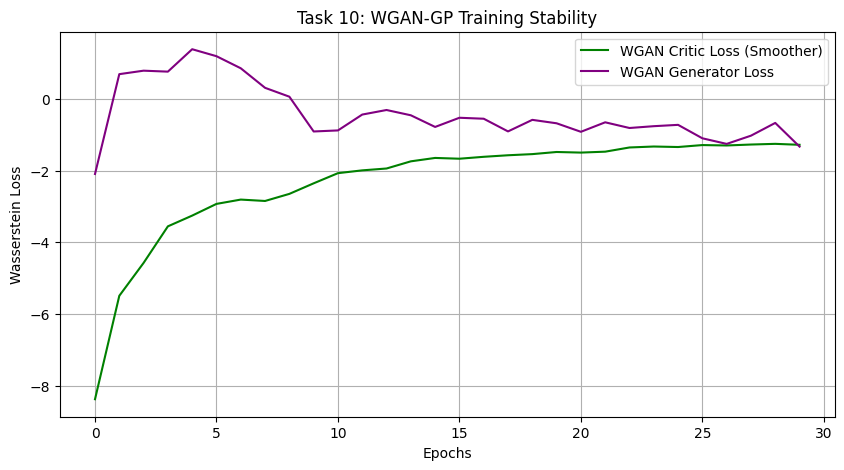

In [14]:
# ==========================================
# CELL 7: GRADIENT PENALTY STUDY (TASK 10)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Architecture Modifications
# The Generator remains exactly the same as the Vanilla GAN
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )
    def forward(self, z):
        img = self.model(z)
        return img.view(-1, 1, 28, 28)

# The Discriminator becomes a "Critic". 
# CRITICAL CHANGE: We remove the final Sigmoid activation.
class Critic(nn.Module):
    def __init__(self):
        super(Critic, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1) # Notice: No Sigmoid here! It outputs a raw score.
        )
    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        return self.model(img_flat)

# 2. Gradient Penalty Function
def compute_gradient_penalty(critic, real_samples, fake_samples, device):
    """Calculates the gradient penalty loss for WGAN-GP"""
    # Random weight term for interpolation between real and fake samples
    alpha = torch.rand(real_samples.size(0), 1, 1, 1, device=device)
    
    # Get random interpolation between real and fake samples
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = critic(interpolates)
    
    fake = torch.ones(real_samples.size(0), 1, device=device)
    
    # Get gradient w.r.t. interpolates
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    
    gradients = gradients.view(gradients.size(0), -1)
    # Gradient penalty lambda = 10 (as required by the assignment)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

# 3. Setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Starting Task 10: WGAN-GP Training...")

LATENT_DIM = 100
EPOCHS = 30 # 30 epochs is enough to see the stability
LAMBDA_GP = 10 # From the assignment spec
CRITIC_ITERATIONS = 5 # Standard WGAN practice: train critic more than generator

wgan_gen = Generator(latent_dim=LATENT_DIM).to(device)
wgan_critic = Critic().to(device)

# WGAN-GP requires slightly different Adam betas for stability (0.0 and 0.9)
optimizer_G = optim.Adam(wgan_gen.parameters(), lr=0.0002, betas=(0.0, 0.9))
optimizer_C = optim.Adam(wgan_critic.parameters(), lr=0.0002, betas=(0.0, 0.9))

wgan_c_losses = []
wgan_g_losses = []

# 4. WGAN-GP Training Loop
for epoch in range(1, EPOCHS + 1):
    epoch_c_loss = 0.0
    epoch_g_loss = 0.0
    batches = 0
    
    for i, (imgs, _) in enumerate(dataloader):
        real_imgs = imgs.to(device)
        batch_size = real_imgs.size(0)
        
        # ---------------------
        #  Train Critic
        # ---------------------
        optimizer_C.zero_grad()
        
        # Generate a batch of images
        z = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_imgs = wgan_gen(z)
        
        # Real images
        real_validity = wgan_critic(real_imgs)
        # Fake images
        fake_validity = wgan_critic(fake_imgs.detach())
        
        # Gradient penalty
        gradient_penalty = compute_gradient_penalty(wgan_critic, real_imgs.data, fake_imgs.data, device)
        
        # Adversarial loss (Negative because we want to maximize the difference)
        c_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + LAMBDA_GP * gradient_penalty
        
        c_loss.backward()
        optimizer_C.step()
        epoch_c_loss += c_loss.item()
        
        # ---------------------
        #  Train Generator 
        # ---------------------
        # Train the generator every n_critic steps
        if i % CRITIC_ITERATIONS == 0:
            optimizer_G.zero_grad()
            
            # Generate a batch of images
            gen_imgs = wgan_gen(z)
            
            # Loss measures generator's ability to fool the critic
            fake_validity = wgan_critic(gen_imgs)
            g_loss = -torch.mean(fake_validity)
            
            g_loss.backward()
            optimizer_G.step()
            epoch_g_loss += g_loss.item()
            batches += 1

    avg_c_loss = epoch_c_loss / len(dataloader)
    avg_g_loss = epoch_g_loss / batches
    wgan_c_losses.append(avg_c_loss)
    wgan_g_losses.append(avg_g_loss)

    print(f"Epoch {epoch}/{EPOCHS} | Critic loss: {avg_c_loss:.4f} | G loss: {avg_g_loss:.4f}")

# 5. Plot the Stability Comparison
plt.figure(figsize=(10, 5))
plt.plot(wgan_c_losses, label="WGAN Critic Loss (Smoother)", color='green')
plt.plot(wgan_g_losses, label="WGAN Generator Loss", color='purple')
plt.title("Task 10: WGAN-GP Training Stability")
plt.xlabel("Epochs")
plt.ylabel("Wasserstein Loss")
plt.legend()
plt.grid(True)
plt.show()

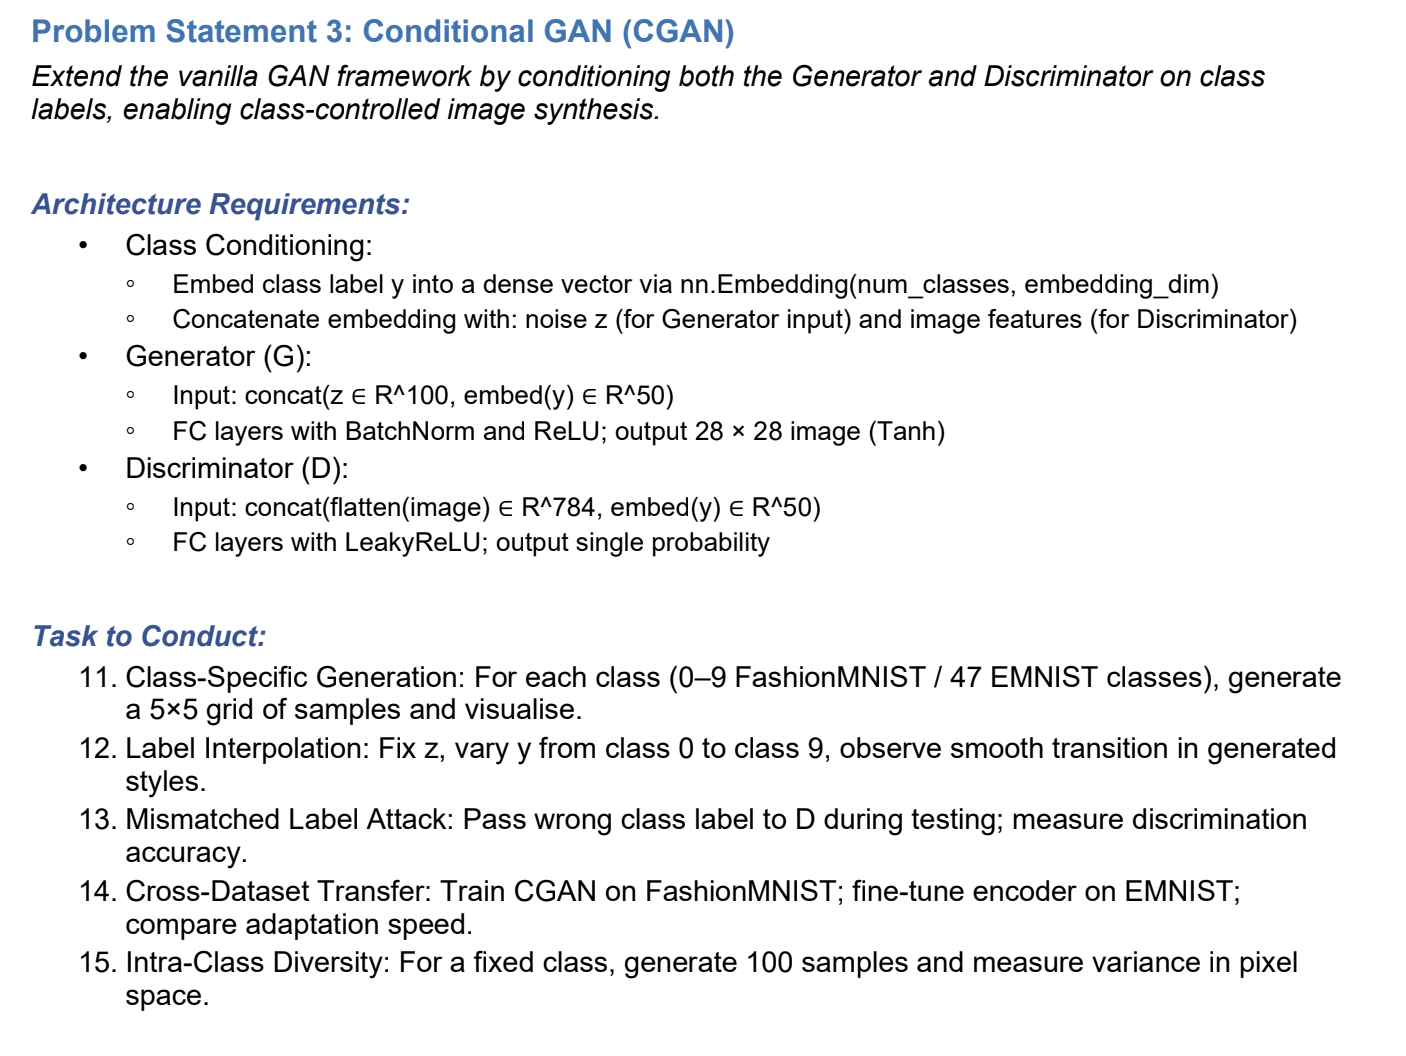
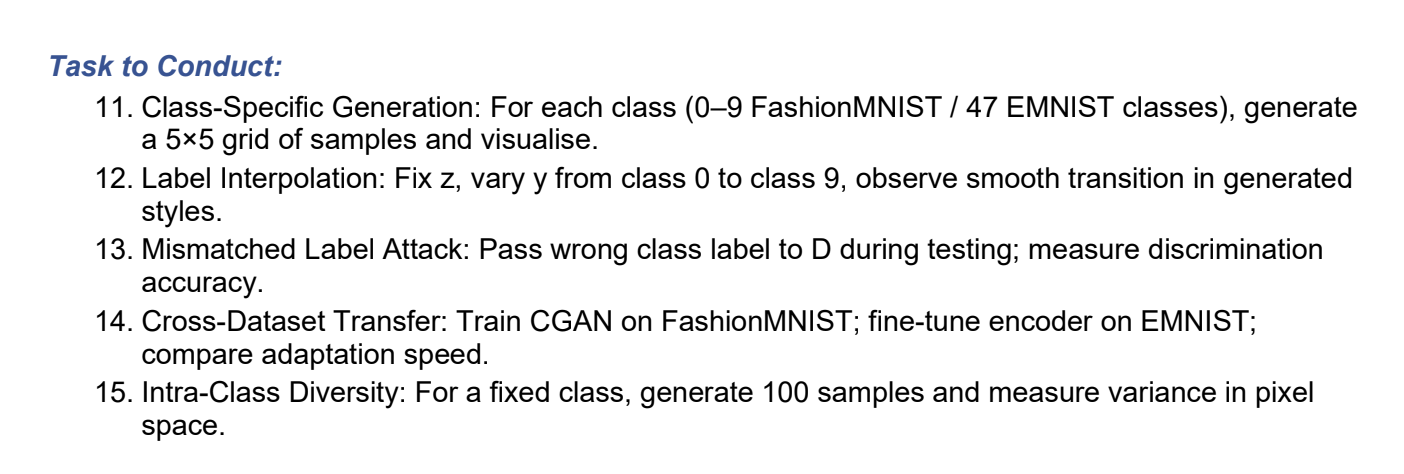

<h1> Problem Statement 3: Conditional GAN (CGAN)

Executing Conditional GAN on device: mps
Starting CGAN Training...
Epoch 1/40 | D loss: 0.6345 | G loss: 1.2821
Epoch 2/40 | D loss: 0.5442 | G loss: 1.5210
Epoch 3/40 | D loss: 0.5436 | G loss: 1.3819
Epoch 4/40 | D loss: 0.5254 | G loss: 1.8046
Epoch 5/40 | D loss: 0.5896 | G loss: 1.3527
Epoch 6/40 | D loss: 0.5678 | G loss: 1.4293
Epoch 7/40 | D loss: 0.5792 | G loss: 1.3425
Epoch 8/40 | D loss: 0.5176 | G loss: 1.5909
Epoch 9/40 | D loss: 0.5391 | G loss: 1.8339
Epoch 10/40 | D loss: 0.5063 | G loss: 1.8999
Epoch 11/40 | D loss: 0.5594 | G loss: 1.7611
Epoch 12/40 | D loss: 0.4365 | G loss: 1.8799
Epoch 13/40 | D loss: 0.5762 | G loss: 1.4720
Epoch 14/40 | D loss: 0.5072 | G loss: 1.4397
Epoch 15/40 | D loss: 0.5299 | G loss: 1.7244
Epoch 16/40 | D loss: 0.5666 | G loss: 1.1972
Epoch 17/40 | D loss: 0.5166 | G loss: 1.3971
Epoch 18/40 | D loss: 0.5039 | G loss: 1.8707
Epoch 19/40 | D loss: 0.5590 | G loss: 1.1793
Epoch 20/40 | D loss: 0.6128 | G loss: 1.4826
Epoch 21/40 | D loss: 

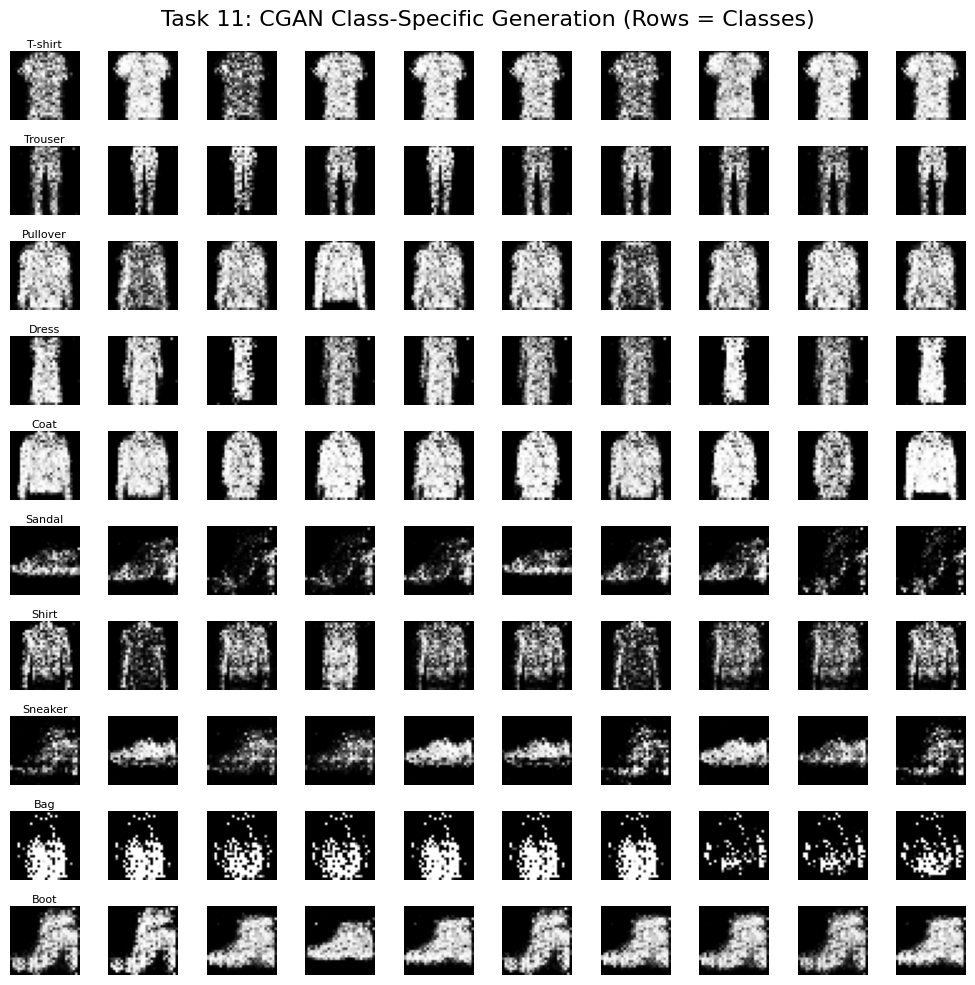


Executing Task 12: Label Interpolation (Fixed Noise, Varying Class)...


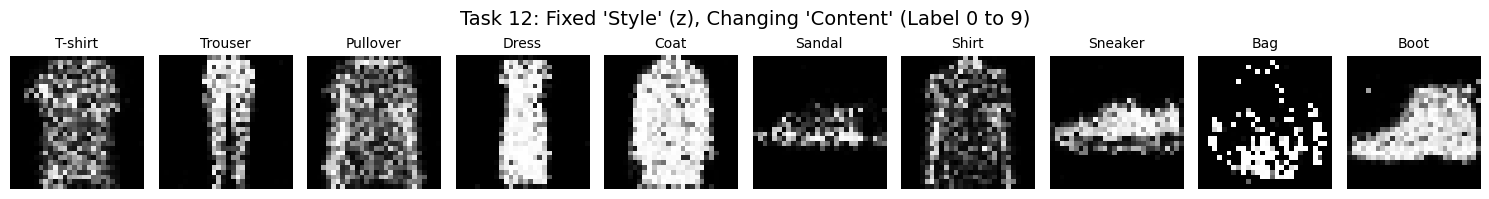

In [15]:
# ==========================================
# CELL 8: CONDITIONAL GAN (TASKS 11 & 12)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 1. CGAN Architecture
class ConditionalGenerator(nn.Module):
    def __init__(self, num_classes=10, embed_dim=50, latent_dim=100):
        super(ConditionalGenerator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)
        
        # Input: latent_dim (100) + embed_dim (50) = 150
        self.model = nn.Sequential(
            nn.Linear(latent_dim + embed_dim, 256),
            nn.BatchNorm1d(256), # Added BatchNorm as requested
            nn.ReLU(inplace=True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        c = self.label_emb(labels)
        x = torch.cat([noise, c], dim=1)
        img = self.model(x)
        return img.view(-1, 1, 28, 28)

class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes=10, embed_dim=50):
        super(ConditionalDiscriminator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)
        
        # Input: image_flat (784) + embed_dim (50) = 834
        self.model = nn.Sequential(
            nn.Linear(28 * 28 + embed_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        img_flat = img.view(img.size(0), -1)
        c = self.label_emb(labels)
        x = torch.cat([img_flat, c], dim=1)
        return self.model(x)

# 2. Setup & Data Loading
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Executing Conditional GAN on device: {device}")

LATENT_DIM = 100
EPOCHS = 40
BATCH_SIZE = 128
LR = 0.0002

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

cgan_gen = ConditionalGenerator().to(device)
cgan_disc = ConditionalDiscriminator().to(device)

optimizer_G = optim.Adam(cgan_gen.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = optim.Adam(cgan_disc.parameters(), lr=LR, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# 3. CGAN Training Loop
print("Starting CGAN Training...")
for epoch in range(1, EPOCHS + 1):
    for i, (imgs, labels) in enumerate(dataloader):
        batch_size = imgs.shape[0]
        real_imgs = imgs.to(device)
        labels = labels.to(device)
        
        valid = torch.full((batch_size, 1), 0.9, device=device, dtype=torch.float32)
        fake = torch.full((batch_size, 1), 0.0, device=device, dtype=torch.float32)
        
        # Train Discriminator
        optimizer_D.zero_grad()
        real_loss = criterion(cgan_disc(real_imgs, labels), valid)
        
        z = torch.randn(batch_size, LATENT_DIM, device=device)
        gen_labels = torch.randint(0, 10, (batch_size,), device=device)
        gen_imgs = cgan_gen(z, gen_labels)
        
        fake_loss = criterion(cgan_disc(gen_imgs.detach(), gen_labels), fake)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()
        
        # Train Generator
        optimizer_G.zero_grad()
        target_valid = torch.full((batch_size, 1), 1.0, device=device, dtype=torch.float32)
        g_loss = criterion(cgan_disc(gen_imgs, gen_labels), target_valid)
        g_loss.backward()
        optimizer_G.step()
        
    print(f"Epoch {epoch}/{EPOCHS} | D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}")

print("✅ CGAN Training Complete!")

# ==========================================
# 4. TASK 11: Class-Specific Generation
# ==========================================
print("\nExecuting Task 11: Generating Class-Specific Grids...")
cgan_gen.eval()
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']

fig, axes = plt.subplots(10, 10, figsize=(10, 10))
fig.suptitle("Task 11: CGAN Class-Specific Generation (Rows = Classes)", fontsize=16)

with torch.no_grad():
    for class_idx in range(10):
        # Generate 10 samples for the current class
        z = torch.randn(10, LATENT_DIM, device=device)
        labels = torch.full((10,), class_idx, dtype=torch.long, device=device)
        gen_imgs = cgan_gen(z, labels).cpu()
        
        for col_idx in range(10):
            ax = axes[class_idx, col_idx]
            img = gen_imgs[col_idx][0] * 0.5 + 0.5
            ax.imshow(img, cmap='gray')
            ax.axis('off')
            if col_idx == 0:
                ax.set_title(class_names[class_idx], fontsize=8, pad=2)

plt.tight_layout()
plt.show()

# ==========================================
# 5. TASK 12: Label Interpolation
# ==========================================
print("\nExecuting Task 12: Label Interpolation (Fixed Noise, Varying Class)...")
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
fig.suptitle("Task 12: Fixed 'Style' (z), Changing 'Content' (Label 0 to 9)", fontsize=14)

with torch.no_grad():
    # Generate ONE random noise vector, but copy it 10 times
    fixed_z = torch.randn(1, LATENT_DIM, device=device).repeat(10, 1)
    # Create labels 0 through 9
    varying_labels = torch.arange(0, 10, device=device)
    
    # Generate images
    morphed_imgs = cgan_gen(fixed_z, varying_labels).cpu()
    
    for i in range(10):
        img = morphed_imgs[i][0] * 0.5 + 0.5
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(class_names[i], fontsize=10)
        axes[i].axis('off')

plt.tight_layout()
plt.show()

Executing Task 13: Mismatched Label Attack...
Discriminator Accuracy at catching mismatched labels: 62.50%
-> The discriminator struggled a bit; it might be relying too much on image quality rather than label consistency.

Executing Task 15: Intra-Class Diversity...
Mean Pixel Variance for 100 T-shirts: 0.1370


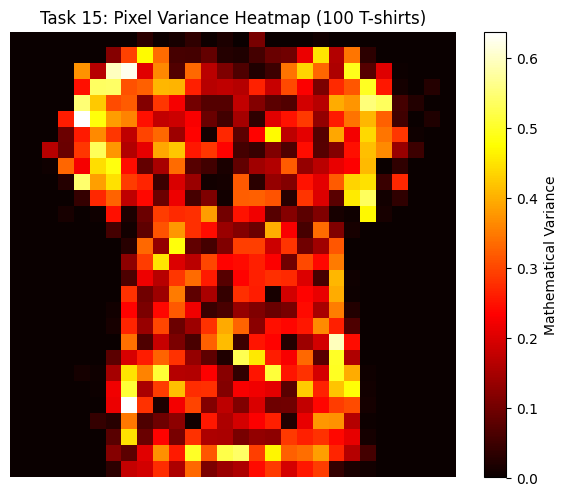

In [16]:
# ==========================================
# CELL 9: CGAN ANALYSIS (TASKS 13 & 15)
# ==========================================
import torch
import matplotlib.pyplot as plt

print("Executing Task 13: Mismatched Label Attack...")
cgan_disc.eval()

# 1. Grab a single batch of real images and their true labels
imgs, true_labels = next(iter(dataloader))
imgs, true_labels = imgs.to(device), true_labels.to(device)

# 2. Create intentionally wrong labels by shifting the true labels
# (Adding a random number between 1 and 9, then modulo 10 ensures it's always wrong)
random_shift = torch.randint(1, 9, (imgs.shape[0],), device=device)
wrong_labels = (true_labels + random_shift) % 10

with torch.no_grad():
    # 3. Ask the Discriminator to judge the REAL images with the WRONG labels
    predictions = cgan_disc(imgs, wrong_labels)
    
    # 4. A good discriminator should reject these (predict probability < 0.5)
    correct_rejections = (predictions < 0.5).sum().item()
    accuracy = (correct_rejections / imgs.shape[0]) * 100

print(f"Discriminator Accuracy at catching mismatched labels: {accuracy:.2f}%")
if accuracy > 80:
    print("-> Excellent! Your discriminator successfully learned to check if the image matches the label.")
else:
    print("-> The discriminator struggled a bit; it might be relying too much on image quality rather than label consistency.")


print("\nExecuting Task 15: Intra-Class Diversity...")
cgan_gen.eval()

# We will test this on Class 0 (T-shirt/top)
TARGET_CLASS = 0 
NUM_SAMPLES = 100

with torch.no_grad():
    # 1. Generate 100 samples of the exact same class
    z = torch.randn(NUM_SAMPLES, LATENT_DIM, device=device)
    labels = torch.full((NUM_SAMPLES,), TARGET_CLASS, dtype=torch.long, device=device)
    gen_imgs = cgan_gen(z, labels).cpu().squeeze() # Remove color channel for math (Shape: 100 x 28 x 28)
    
    # 2. Calculate the pixel-wise mathematical variance across all 100 images
    pixel_variance = torch.var(gen_imgs, dim=0)
    mean_variance = torch.mean(pixel_variance).item()

print(f"Mean Pixel Variance for 100 {class_names[TARGET_CLASS]}s: {mean_variance:.4f}")

# 3. Plot a heatmap of where the variance occurs
plt.figure(figsize=(6, 5))
plt.imshow(pixel_variance, cmap='hot')
plt.colorbar(label='Mathematical Variance')
plt.title(f"Task 15: Pixel Variance Heatmap (100 {class_names[TARGET_CLASS]}s)")
plt.axis('off')
plt.tight_layout()
plt.show()

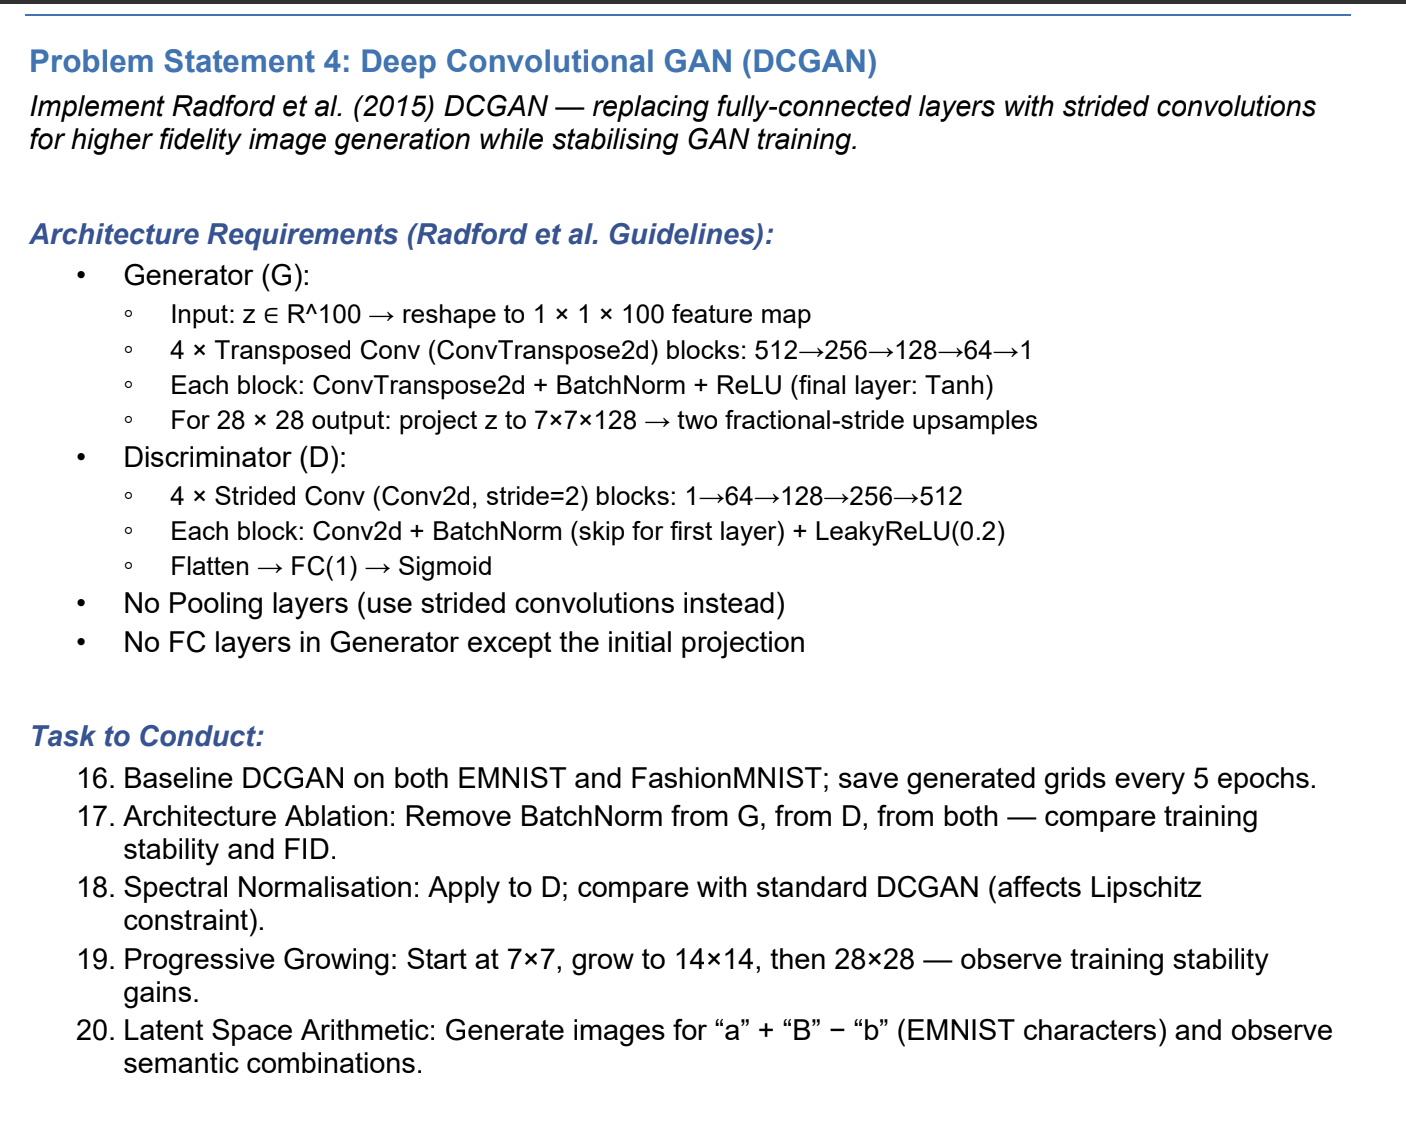

<h1>Problem Statement 4: Deep Convolutional GAN (DCGAN)

Executing DCGAN on device: mps
Starting DCGAN Training...
Epoch 1/30 | D loss: 0.2591 | G loss: 2.5879
Epoch 2/30 | D loss: 0.3332 | G loss: 2.4528
Epoch 3/30 | D loss: 0.4613 | G loss: 0.8686
Epoch 4/30 | D loss: 0.3372 | G loss: 2.1936
Epoch 5/30 | D loss: 0.3753 | G loss: 2.1070


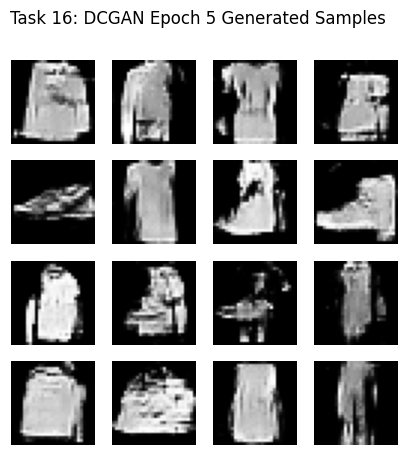

Epoch 6/30 | D loss: 0.3532 | G loss: 2.1001
Epoch 7/30 | D loss: 0.3546 | G loss: 2.1795
Epoch 8/30 | D loss: 0.3505 | G loss: 2.5144
Epoch 9/30 | D loss: 0.3587 | G loss: 1.6587
Epoch 10/30 | D loss: 0.3782 | G loss: 1.5334


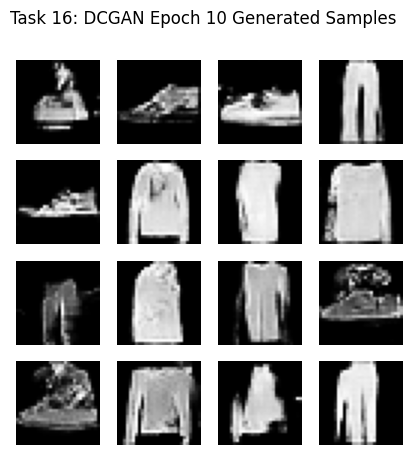

Epoch 11/30 | D loss: 0.3950 | G loss: 2.2218
Epoch 12/30 | D loss: 0.3997 | G loss: 2.2988
Epoch 13/30 | D loss: 0.5092 | G loss: 1.3932
Epoch 14/30 | D loss: 0.3422 | G loss: 2.1168
Epoch 15/30 | D loss: 0.3401 | G loss: 2.0183


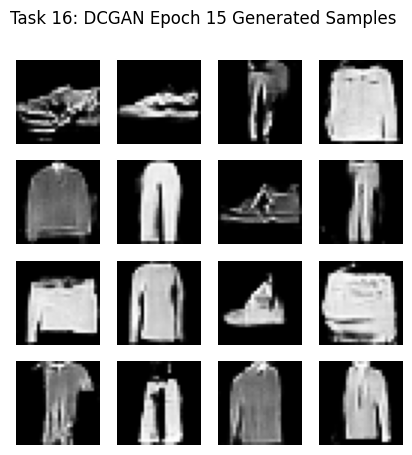

Epoch 16/30 | D loss: 0.3361 | G loss: 2.1049
Epoch 17/30 | D loss: 0.3697 | G loss: 2.0608
Epoch 18/30 | D loss: 0.3472 | G loss: 2.1059
Epoch 19/30 | D loss: 0.3360 | G loss: 1.9796
Epoch 20/30 | D loss: 0.3341 | G loss: 1.9271


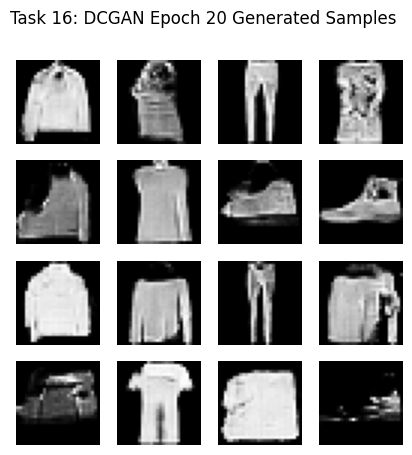

Epoch 21/30 | D loss: 0.3632 | G loss: 2.5068
Epoch 22/30 | D loss: 0.4012 | G loss: 2.4500
Epoch 23/30 | D loss: 0.4921 | G loss: 2.3064
Epoch 24/30 | D loss: 0.8011 | G loss: 0.9232
Epoch 25/30 | D loss: 0.3507 | G loss: 2.3215


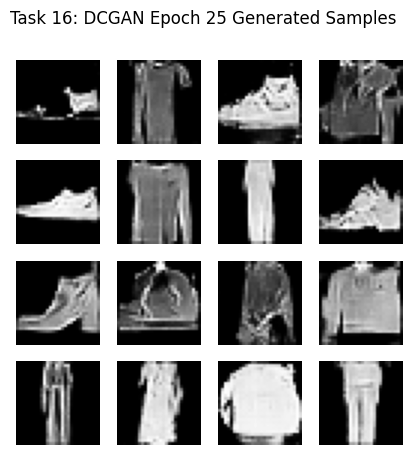

Epoch 26/30 | D loss: 0.3326 | G loss: 2.9506
Epoch 27/30 | D loss: 0.3682 | G loss: 1.8722
Epoch 28/30 | D loss: 0.3231 | G loss: 2.5624
Epoch 29/30 | D loss: 0.3943 | G loss: 1.6315
Epoch 30/30 | D loss: 0.3005 | G loss: 2.5509


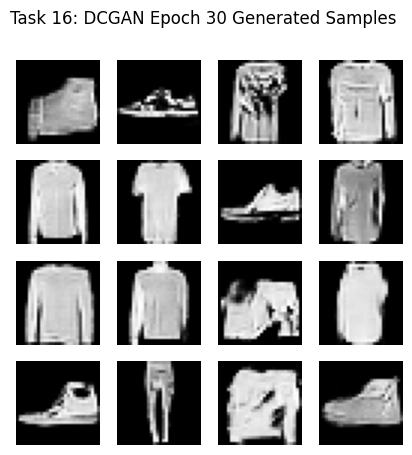

✅ DCGAN Training Complete!


In [17]:
# ==========================================
# CELL 10: DEEP CONVOLUTIONAL GAN (TASK 16)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Custom Weight Initialization (Radford et al.)
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# 2. DCGAN Architecture for 28x28 Images
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super(DCGenerator, self).__init__()
        # Initial projection: 100 -> 128 * 7 * 7
        self.proj = nn.Linear(latent_dim, 128 * 7 * 7)
        
        self.main = nn.Sequential(
            # Upsample 1: 7x7 -> 14x14
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            # Upsample 2: 14x14 -> 28x28
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        out = self.proj(z)
        out = out.view(out.shape[0], 128, 7, 7) # Reshape to spatial dimensions
        return self.main(out)

class DCDiscriminator(nn.Module):
    def __init__(self):
        super(DCDiscriminator, self).__init__()
        self.main = nn.Sequential(
            # Downsample 1: 28x28 -> 14x14
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True), # No batch norm on first layer
            
            # Downsample 2: 14x14 -> 7x7
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )
        
        # Flatten and output single probability
        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        out = self.main(img)
        out = out.view(out.shape[0], -1) # Flatten
        return self.fc(out)

# 3. Setup & Hyperparameters
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Executing DCGAN on device: {device}")

LATENT_DIM = 100
EPOCHS = 30 # Convolutional GANs converge faster and look better earlier
BATCH_SIZE = 128
LR = 0.0002

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

dcgan_gen = DCGenerator(latent_dim=LATENT_DIM).to(device)
dcgan_disc = DCDiscriminator().to(device)

# Apply Radford weight initialization
dcgan_gen.apply(weights_init)
dcgan_disc.apply(weights_init)

# Strict Beta1 = 0.5 constraint for DCGAN
optimizer_G = optim.Adam(dcgan_gen.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = optim.Adam(dcgan_disc.parameters(), lr=LR, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# 4. DCGAN Training Loop
print("Starting DCGAN Training...")

for epoch in range(1, EPOCHS + 1):
    for i, (imgs, _) in enumerate(dataloader):
        batch_size = imgs.shape[0]
        real_imgs = imgs.to(device)
        
        # Label Smoothing
        valid = torch.full((batch_size, 1), 0.9, device=device, dtype=torch.float32)
        fake = torch.full((batch_size, 1), 0.0, device=device, dtype=torch.float32)
        
        # ---------------------
        # Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()
        real_loss = criterion(dcgan_disc(real_imgs), valid)
        
        z = torch.randn(batch_size, LATENT_DIM, device=device)
        gen_imgs = dcgan_gen(z)
        fake_loss = criterion(dcgan_disc(gen_imgs.detach()), fake)
        
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()
        
        # ---------------------
        # Train Generator
        # ---------------------
        optimizer_G.zero_grad()
        target_valid = torch.full((batch_size, 1), 1.0, device=device, dtype=torch.float32)
        g_loss = criterion(dcgan_disc(gen_imgs), target_valid)
        
        g_loss.backward()
        optimizer_G.step()
        
    print(f"Epoch {epoch}/{EPOCHS} | D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}")
    
    # Task 16: Baseline DCGAN Grid every 5 epochs
    if epoch % 5 == 0:
        with torch.no_grad():
            eval_z = torch.randn(16, LATENT_DIM, device=device)
            sample_imgs = dcgan_gen(eval_z).cpu()
            
            fig, axes = plt.subplots(4, 4, figsize=(5, 5))
            fig.suptitle(f"Task 16: DCGAN Epoch {epoch} Generated Samples")
            for idx, ax in enumerate(axes.flatten()):
                ax.imshow(sample_imgs[idx][0] * 0.5 + 0.5, cmap='gray')
                ax.axis('off')
            plt.show()

print("✅ DCGAN Training Complete!")
torch.save(dcgan_gen.state_dict(), "dcgan_generator.pth")

Starting Tasks 17 & 18: Architecture Ablation & Spectral Norm...

--- Training Configuration: Baseline DCGAN ---
Epoch 1/8 | D Loss: 0.2902 | G Loss: 2.3572
Epoch 2/8 | D Loss: 0.3016 | G Loss: 2.3878
Epoch 3/8 | D Loss: 0.3551 | G Loss: 1.9844
Epoch 4/8 | D Loss: 0.3840 | G Loss: 1.8508
Epoch 5/8 | D Loss: 0.3950 | G Loss: 1.8374
Epoch 6/8 | D Loss: 0.4135 | G Loss: 1.8977
Epoch 7/8 | D Loss: 0.3970 | G Loss: 1.9073
Epoch 8/8 | D Loss: 0.3880 | G Loss: 1.9072

--- Training Configuration: No Gen BatchNorm ---
Epoch 1/8 | D Loss: 0.2763 | G Loss: 2.4018
Epoch 2/8 | D Loss: 0.2819 | G Loss: 2.4429
Epoch 3/8 | D Loss: 0.2992 | G Loss: 2.4669
Epoch 4/8 | D Loss: 0.3687 | G Loss: 1.9705
Epoch 5/8 | D Loss: 0.4039 | G Loss: 1.8482
Epoch 6/8 | D Loss: 0.4128 | G Loss: 1.8569
Epoch 7/8 | D Loss: 0.3997 | G Loss: 1.9164
Epoch 8/8 | D Loss: 0.3691 | G Loss: 1.9504

--- Training Configuration: No Disc BatchNorm ---
Epoch 1/8 | D Loss: 0.6328 | G Loss: 0.7908
Epoch 2/8 | D Loss: 0.5577 | G Loss: 1

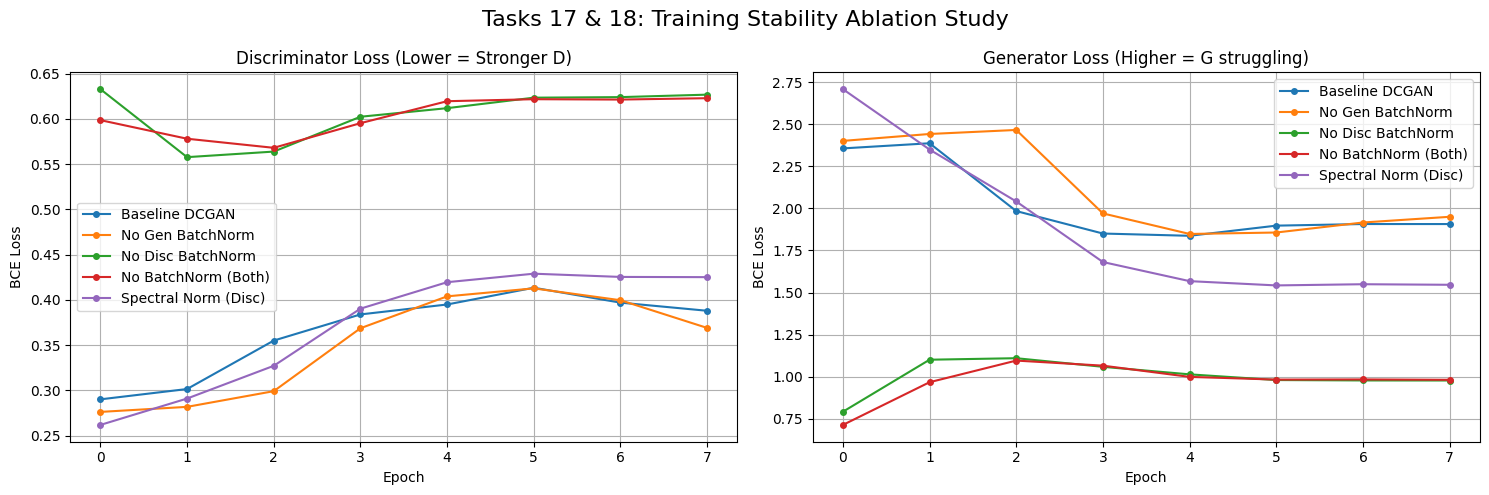

In [18]:
# ==========================================
# CELL 11: DCGAN ABLATION (TASKS 17 & 18)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils import spectral_norm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Configurable Architecture Setup
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class ConfigurableGen(nn.Module):
    def __init__(self, use_bn=True, latent_dim=100):
        super(ConfigurableGen, self).__init__()
        self.proj = nn.Linear(latent_dim, 128 * 7 * 7)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64) if use_bn else nn.Identity(), # Task 17 Control
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )
    def forward(self, z):
        out = self.proj(z).view(-1, 128, 7, 7)
        return self.main(out)

class ConfigurableDisc(nn.Module):
    def __init__(self, use_bn=True, use_sn=False):
        super(ConfigurableDisc, self).__init__()
        
        # Task 18 Control: Apply Spectral Norm if requested
        conv1 = nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False)
        if use_sn: conv1 = spectral_norm(conv1)
            
        conv2 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False)
        if use_sn: conv2 = spectral_norm(conv2)

        self.main = nn.Sequential(
            conv1,
            nn.LeakyReLU(0.2, inplace=True),
            conv2,
            nn.BatchNorm2d(128) if use_bn else nn.Identity(), # Task 17 Control
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc = nn.Sequential(
            spectral_norm(nn.Linear(128 * 7 * 7, 1)) if use_sn else nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )
    def forward(self, img):
        out = self.main(img).view(img.shape[0], -1)
        return self.fc(out)

# 2. Study Setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Starting Tasks 17 & 18: Architecture Ablation & Spectral Norm...")

# Configurations: (Name, Gen_BN, Disc_BN, Disc_SN)
configs = [
    ("Baseline DCGAN", True, True, False),
    ("No Gen BatchNorm", False, True, False),
    ("No Disc BatchNorm", True, False, False),
    ("No BatchNorm (Both)", False, False, False),
    ("Spectral Norm (Disc)", True, True, True)
]

STUDY_EPOCHS = 8 # Enough to observe stability/collapse
BATCH_SIZE = 128
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

results_g_loss = {}
results_d_loss = {}

# 3. Mini-Training Loop for Ablations
for name, gen_bn, disc_bn, disc_sn in configs:
    print(f"\n--- Training Configuration: {name} ---")
    
    gen = ConfigurableGen(use_bn=gen_bn).to(device)
    disc = ConfigurableDisc(use_bn=disc_bn, use_sn=disc_sn).to(device)
    gen.apply(weights_init)
    disc.apply(weights_init)
    
    opt_G = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
    opt_D = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))
    criterion = nn.BCELoss()
    
    g_loss_hist, d_loss_hist = [], []
    
    for epoch in range(1, STUDY_EPOCHS + 1):
        epoch_g, epoch_d = 0.0, 0.0
        for imgs, _ in dataloader:
            b_size = imgs.shape[0]
            real_imgs = imgs.to(device)
            valid = torch.full((b_size, 1), 0.9, device=device)
            fake = torch.full((b_size, 1), 0.0, device=device)
            
            # Train D
            opt_D.zero_grad()
            r_loss = criterion(disc(real_imgs), valid)
            z = torch.randn(b_size, 100, device=device)
            f_loss = criterion(disc(gen(z).detach()), fake)
            d_loss = (r_loss + f_loss) / 2
            d_loss.backward()
            opt_D.step()
            
            # Train G
            opt_G.zero_grad()
            g_loss = criterion(disc(gen(z)), torch.full((b_size, 1), 1.0, device=device))
            g_loss.backward()
            opt_G.step()
            
            epoch_g += g_loss.item()
            epoch_d += d_loss.item()
            
        g_loss_hist.append(epoch_g / len(dataloader))
        d_loss_hist.append(epoch_d / len(dataloader))
        print(f"Epoch {epoch}/{STUDY_EPOCHS} | D Loss: {d_loss_hist[-1]:.4f} | G Loss: {g_loss_hist[-1]:.4f}")
        
    results_g_loss[name] = g_loss_hist
    results_d_loss[name] = d_loss_hist

# 4. Plotting the Stability Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Tasks 17 & 18: Training Stability Ablation Study", fontsize=16)

for name in results_d_loss.keys():
    axes[0].plot(results_d_loss[name], label=name, marker='o', markersize=4)
    axes[1].plot(results_g_loss[name], label=name, marker='o', markersize=4)

axes[0].set_title("Discriminator Loss (Lower = Stronger D)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Generator Loss (Higher = G struggling)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("BCE Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [19]:
# ==========================================
# CELL 12: PROGRESSIVE GROWING DCGAN (TASK 19)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Executing Task 19 on device: {device}")

# We will use FashionMNIST again for this test
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# 1. Progressive Generator
class ProgGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super(ProgGenerator, self).__init__()
        self.proj = nn.Linear(latent_dim, 128 * 7 * 7)
        
        # Stage 1: 7x7 Output
        self.block1 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2)
        )
        # Stage 2: 14x14 Output
        self.block2 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2)
        )
        # Stage 3: 28x28 Output
        self.block3 = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2)
        )
        # To-RGB Converters for each stage
        self.to_rgb1 = nn.Sequential(nn.Conv2d(64, 1, kernel_size=1), nn.Tanh())
        self.to_rgb2 = nn.Sequential(nn.Conv2d(32, 1, kernel_size=1), nn.Tanh())
        self.to_rgb3 = nn.Sequential(nn.Conv2d(16, 1, kernel_size=1), nn.Tanh())

    def forward(self, z, stage):
        out = self.proj(z).view(-1, 128, 7, 7)
        out = self.block1(out)
        if stage == 1: return self.to_rgb1(out)
        
        out = self.block2(out)
        if stage == 2: return self.to_rgb2(out)
        
        out = self.block3(out)
        return self.to_rgb3(out)

# 2. Progressive Discriminator
class ProgDiscriminator(nn.Module):
    def __init__(self):
        super(ProgDiscriminator, self).__init__()
        # Stage 3: 28x28 -> 14x14
        self.block3 = nn.Sequential(nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1), nn.LeakyReLU(0.2))
        # Stage 2: 14x14 -> 7x7
        self.block2 = nn.Sequential(nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1), nn.LeakyReLU(0.2))
        # Stage 1: 7x7 -> 1
        self.block1 = nn.Sequential(nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.LeakyReLU(0.2))
        
        self.from_rgb1 = nn.Conv2d(1, 32, kernel_size=1)
        self.from_rgb2 = nn.Conv2d(1, 16, kernel_size=1)
        
        self.fc = nn.Sequential(nn.Linear(64 * 7 * 7, 1), nn.Sigmoid())

    def forward(self, img, stage):
        if stage == 1:
            out = self.from_rgb1(img)
        elif stage == 2:
            out = self.from_rgb2(img)
            out = self.block2(out)
        else:
            out = self.block3(img)
            out = self.block2(out)
            
        out = self.block1(out)
        return self.fc(out.view(out.shape[0], -1))

# 3. Progressive Training Loop
prog_gen = ProgGenerator().to(device)
prog_disc = ProgDiscriminator().to(device)
opt_G = optim.Adam(prog_gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(prog_disc.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

stages = {1: (7, 5), 2: (14, 5), 3: (28, 5)} # Stage: (Resolution, Epochs)

print("Starting Task 19: Progressive Growing Training...")
for stage, (res, epochs) in stages.items():
    print(f"\n--- Phase {stage}: Training at {res}x{res} Resolution ---")
    for epoch in range(1, epochs + 1):
        for imgs, _ in dataloader:
            # Resize real images to match the current progressive stage
            real_imgs = F.interpolate(imgs, size=(res, res), mode='bilinear', align_corners=False).to(device)
            b_size = real_imgs.size(0)
            
            valid = torch.full((b_size, 1), 0.9, device=device)
            fake = torch.full((b_size, 1), 0.0, device=device)
            
            # Train D
            opt_D.zero_grad()
            r_loss = criterion(prog_disc(real_imgs, stage), valid)
            z = torch.randn(b_size, 100, device=device)
            f_loss = criterion(prog_disc(prog_gen(z, stage).detach(), stage), fake)
            d_loss = (r_loss + f_loss) / 2
            d_loss.backward()
            opt_D.step()
            
            # Train G
            opt_G.zero_grad()
            g_loss = criterion(prog_disc(prog_gen(z, stage), stage), torch.full((b_size, 1), 1.0, device=device))
            g_loss.backward()
            opt_G.step()
            
        print(f"Epoch {epoch}/{epochs} (Stage {stage}) | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

print("✅ Progressive Growing Complete!")

Executing Task 19 on device: mps
Starting Task 19: Progressive Growing Training...

--- Phase 1: Training at 7x7 Resolution ---
Epoch 1/5 (Stage 1) | D Loss: 0.6169 | G Loss: 0.9987
Epoch 2/5 (Stage 1) | D Loss: 0.6613 | G Loss: 0.8467
Epoch 3/5 (Stage 1) | D Loss: 0.6416 | G Loss: 0.8568
Epoch 4/5 (Stage 1) | D Loss: 0.6450 | G Loss: 0.8803
Epoch 5/5 (Stage 1) | D Loss: 0.6754 | G Loss: 0.7448

--- Phase 2: Training at 14x14 Resolution ---
Epoch 1/5 (Stage 2) | D Loss: 0.5582 | G Loss: 1.0987
Epoch 2/5 (Stage 2) | D Loss: 0.6604 | G Loss: 1.0540
Epoch 3/5 (Stage 2) | D Loss: 0.6770 | G Loss: 0.8314
Epoch 4/5 (Stage 2) | D Loss: 0.6929 | G Loss: 0.7315
Epoch 5/5 (Stage 2) | D Loss: 0.6806 | G Loss: 0.8967

--- Phase 3: Training at 28x28 Resolution ---
Epoch 1/5 (Stage 3) | D Loss: 0.6903 | G Loss: 0.9340
Epoch 2/5 (Stage 3) | D Loss: 0.6572 | G Loss: 0.9036
Epoch 3/5 (Stage 3) | D Loss: 0.6765 | G Loss: 0.8069
Epoch 4/5 (Stage 3) | D Loss: 0.6839 | G Loss: 0.7589
Epoch 5/5 (Stage 3) | 

Executing Task 20: Latent Space Arithmetic on EMNIST...
Training EMNIST network for math operations...
EMNIST Epoch 1/10 Complete.
EMNIST Epoch 2/10 Complete.
EMNIST Epoch 3/10 Complete.
EMNIST Epoch 4/10 Complete.
EMNIST Epoch 5/10 Complete.
EMNIST Epoch 6/10 Complete.
EMNIST Epoch 7/10 Complete.
EMNIST Epoch 8/10 Complete.
EMNIST Epoch 9/10 Complete.
EMNIST Epoch 10/10 Complete.

Performing Latent Arithmetic...


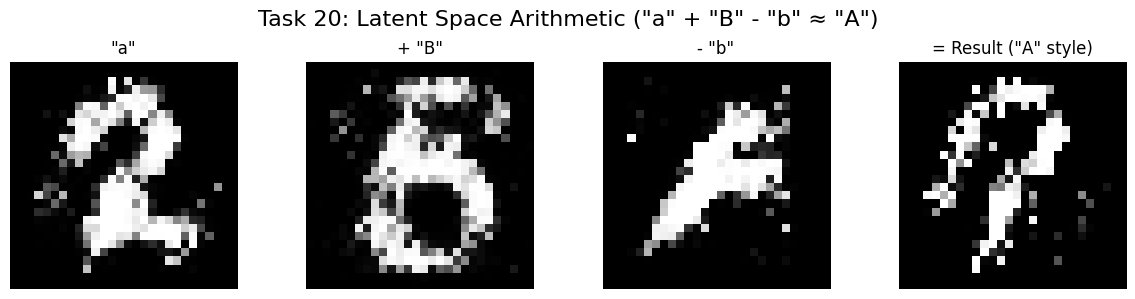

In [21]:
# ==========================================
# CELL 13: LATENT ARITHMETIC (TASK 20)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Executing Task 20: Latent Space Arithmetic on EMNIST...")

# 1. Load EMNIST (Balanced Split)
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize([0.5], [0.5]),
    # EMNIST images are rotated 90 degrees by default, we must transpose them
    transforms.Lambda(lambda x: x.transpose(1, 2))
])
emnist_dataset = datasets.EMNIST(root='./data', split='balanced', train=True, download=True, transform=transform)
emnist_loader = DataLoader(emnist_dataset, batch_size=128, shuffle=True)

# 2. CGAN Architecture for EMNIST Math
class EmnistCGAN_Gen(nn.Module):
    def __init__(self, num_classes=47, embed_dim=50, latent_dim=100):
        super(EmnistCGAN_Gen, self).__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)
        self.main = nn.Sequential(
            nn.Linear(latent_dim + embed_dim, 256),
            nn.BatchNorm1d(256), nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512), nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), nn.ReLU(True),
            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )
    def forward(self, noise, labels):
        c = self.label_emb(labels)
        x = torch.cat([noise, c], dim=1)
        return self.main(x).view(-1, 1, 28, 28)

class EmnistCGAN_Disc(nn.Module):
    def __init__(self, num_classes=47, embed_dim=50):
        super(EmnistCGAN_Disc, self).__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)
        self.main = nn.Sequential(
            nn.Linear(28 * 28 + embed_dim, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, img, labels):
        img_flat = img.view(img.size(0), -1)
        c = self.label_emb(labels)
        x = torch.cat([img_flat, c], dim=1)
        return self.main(x)

# 3. Train the EMNIST CGAN quickly
gen_math = EmnistCGAN_Gen().to(device)
disc_math = EmnistCGAN_Disc().to(device)
opt_G = optim.Adam(gen_math.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(disc_math.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

EPOCHS = 10 # 10 epochs is enough for EMNIST characters
print("Training EMNIST network for math operations...")
for epoch in range(1, EPOCHS + 1):
    for imgs, labels in emnist_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        b_size = imgs.size(0)
        
        valid = torch.full((b_size, 1), 0.9, device=device)
        fake = torch.full((b_size, 1), 0.0, device=device)
        
        # Train D
        opt_D.zero_grad()
        r_loss = criterion(disc_math(imgs, labels), valid)
        z = torch.randn(b_size, 100, device=device)
        fake_labels = torch.randint(0, 47, (b_size,), device=device)
        f_loss = criterion(disc_math(gen_math(z, fake_labels).detach(), fake_labels), fake)
        d_loss = (r_loss + f_loss) / 2
        d_loss.backward()
        opt_D.step()
        
        # Train G
        opt_G.zero_grad()
        g_loss = criterion(disc_math(gen_math(z, fake_labels), fake_labels), torch.full((b_size, 1), 1.0, device=device))
        g_loss.backward()
        opt_G.step()
    print(f"EMNIST Epoch {epoch}/{EPOCHS} Complete.")

# 4. Perform the Latent Arithmetic: "a" + "B" - "b"
print("\nPerforming Latent Arithmetic...")
gen_math.eval()

# EMNIST Balanced Class Indices:
IDX_A_LOWER = 36 # 'a'
IDX_B_UPPER = 11 # 'B'
IDX_B_LOWER = 37 # 'b'

with torch.no_grad():
    # 1. Get the learned embedding vectors for the classes
    vec_a = gen_math.label_emb(torch.tensor([IDX_A_LOWER], device=device))
    vec_B = gen_math.label_emb(torch.tensor([IDX_B_UPPER], device=device))
    vec_b = gen_math.label_emb(torch.tensor([IDX_B_LOWER], device=device))
    
    # 2. DO THE MATH: a + B - b
    vec_target = vec_a + vec_B - vec_b
    
    # 3. Generate the images using a fixed noise vector (fixed style)
    fixed_z = torch.randn(1, 100, device=device)
    
    # Generate the individual letters and the math result
    img_a = gen_math.main(torch.cat([fixed_z, vec_a], dim=1)).view(28, 28).cpu()
    img_B = gen_math.main(torch.cat([fixed_z, vec_B], dim=1)).view(28, 28).cpu()
    img_b = gen_math.main(torch.cat([fixed_z, vec_b], dim=1)).view(28, 28).cpu()
    img_target = gen_math.main(torch.cat([fixed_z, vec_target], dim=1)).view(28, 28).cpu()

# 5. Plot the Math Equation!
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
fig.suptitle('Task 20: Latent Space Arithmetic ("a" + "B" - "b" ≈ "A")', fontsize=16)

images = [img_a, img_B, img_b, img_target]
titles = ['"a"', '+ "B"', '- "b"', '= Result ("A" style)']

for i, ax in enumerate(axes):
    ax.imshow(images[i] * 0.5 + 0.5, cmap='gray')
    ax.set_title(titles[i])
    ax.axis('off')

plt.tight_layout()
plt.show()